# 10 m wind speed — data quality review

Cal-Adapt Analytics Engine 10 m wind (`wspeed` / `wspd10mean`), 
1980–2014, evaluated against **station observations** from [HDP](https://github.com/Eagle-Rock-Analytics/historical-obs-platform) first, then against
[CONUS404](https://www.usgs.gov/data/conus404-four-kilometer-long-term-regional-hydroclimate-reanalysis-over-conterminous-united) and [ERA5](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview).


**Compare against observations first**

The first way to review a gridded product that comes to mind is to compare it against
a reanalysis. Looking at the ratio of windspeed between AE's WRF and LOCA2 models and 
ERA5 reanalysis gives 1.5–1.6 over land, which reads as a
60 % error, which is not the case. **ERA5 at 0.25° (~31 km) cannot represent a 3 km
ridge–valley contrast**, so over terrain the two are measuring different things
and neither is wrong for disagreeing.

**What the stations can and cannot be**

They are the **primary reference**, not a common frame in the gridding sense,
and the difference matters:

- **They are points.** A station samples one spot; a LOCA2/WRF cell averages 9 km²
  and an ERA5 cell ~950 km². Part of every model–station difference is this
  footprint mismatch and cannot be removed.
- **They do not cover the ocean**, and they are sparse above 2,000 m — exactly
  where 85 shows the products and ERA5 diverge most.

So, we can still benefit from comparing LOCA2/WRF to a gridded dataset like ERA5 
and CONUS404 for an spatial and seasonal analysis. That is what
§8 uses ERA5 for, as a common grid and a diagnostic, not as truth.

---

## 0. Setup

In [4]:
from data_quality.metrics import region_summary, elevation_summary, pattern_metrics
from data_quality.grids import region_masks, sample_grid_at_points, cos_weights
from data_quality import localdata as L
from dask.diagnostics import ProgressBar
from fastkde import fastKDE
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from cartopy import crs as ccrs
from cartopy import feature as cfeature
import pathlib

# Figure export: static PNGs under figures/png, interactive Plotly under
# figures/html. Every plot cell below is followed by a cell that calls these.
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.colors import to_hex
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 300, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})

ROOT = pathlib.Path("/shared/data")

In [5]:
# Which metrics run to read. Change this one line to switch between the
# full-period build and a windowed one; nothing else in the notebook depends on
# the choice. Set METRICS_ENV to override without editing the notebook.
#
#   metrics            1980-2014, analysis networks only
#   metrics_2005_2014  short window, all networks -- more stations, but only
#                      ten years, so seasonal and interannual results there are
#                      noisier and the level and distribution results are what
#                      the run is for (right now is on hold)
import os
METRICS = os.environ.get("METRICS_DIR", "metrics")
MET = ROOT / METRICS
# One place that decides where figures go. PNGs are the portable
# copy for slides and print; the HTML is what the Quarto site
# embeds. Nothing writes to FIG itself -- a loose PNG beside the
# two subfolders is how the tree ended up duplicated once.
FIG = pathlib.Path("figures")
FIG_PNG = FIG / "png"
FIG_HTML = FIG / "html"
for d in (FIG_PNG, FIG_HTML):
    d.mkdir(parents=True, exist_ok=True)

In [6]:
MET

PosixPath('/shared/data/metrics')

In [7]:
COLOR = {"loca2": "tab:blue", "wrf-gcm": "tab:orange",
         "wrf-era5": "#b34700", "wrf": "tab:orange",
         "conus404": "tab:green", "era5": "0.35", "station": "k"}

In [30]:

# Same colours as the matplotlib figures, as hex so Plotly accepts them.
PCOLOR = {k: to_hex(v) for k, v in COLOR.items()}
# Categorical palette for exposure classes / regions (Plotly's D3 = tab10).
PCAT = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def save_png(fig, name, dpi=300):
    """Save a matplotlib figure as figures/png/<name>.png."""
    path = FIG_PNG / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


def style(pf, title=None, height=450, width=None, hovermode="closest"):
    """One look for every interactive figure."""
    pf.update_layout(
        template="plotly_white", title=dict(text=title, x=0.01, xanchor="left"),
        height=height, width=width, hovermode=hovermode,
        font=dict(family="Inter, Helvetica, Arial, sans-serif", size=12),
        legend=dict(bgcolor="rgba(255,255,255,0.8)", bordercolor="#ddd",
                    borderwidth=1, font=dict(size=11)),
        margin=dict(l=60, r=30, t=70 if title else 40, b=50))
    
    pf.update_xaxes(showline=True, linecolor="#444", mirror=True,
                    gridcolor="#eee", zeroline=False, ticks="outside")
    pf.update_yaxes(showline=True, linecolor="#444", mirror=True,
                    gridcolor="#eee", zeroline=False, ticks="outside")
    # pf.update_layout(
    # autosize=True, height=None, width=None,
    #     margin=dict(l=70, r=30, t=60, b=70),   # b is the one that's short
    # )
    pf.update_xaxes(automargin=True)
    pf.update_yaxes(automargin=True)
    return pf


def save_html(pf, name, show=True):
    """Write figures/html/<name>.html (plotly.js from CDN keeps files small;
    use include_plotlyjs=True instead for fully offline files)."""
    path = FIG_HTML / f"{name}.html"
    pf.write_html(path, include_plotlyjs="cdn", full_html=True,
                  config={"displaylogo": False, "toImageButtonOptions":
                          {"format": "png", "filename": name, "scale": 2}})
    if show:
        pf.show()
    return path


def ref_line(pf, x0, x1, row=None, col=None, **kw):
    """Dashed 1:1 line between (x0, x0) and (x1, x1)."""
    pf.add_trace(go.Scatter(x=[x0, x1], y=[x0, x1], mode="lines",
                            line=dict(color="black", dash="dash", width=1.2),
                            name="1:1", showlegend=False, hoverinfo="skip",
                            **kw), row=row, col=col)


def station_hover(idx=None):
    """customdata + hovertemplate fragment identifying each station."""
    idx = np.arange(len(sids)) if idx is None else np.asarray(idx)
    cd = np.stack([np.asarray(sids)[idx], net[idx], expo[idx]], axis=-1)
    tmpl = ("<b>%{customdata[0]}</b><br>network: %{customdata[1]}"
            "<br>exposure: %{customdata[2]}")
    return cd, tmpl


In [14]:
# Two PRODUCTS, not three. WRF-ERA5 is the same WRF configuration as the five
# GCM-driven runs, differing only in its boundary conditions -- so it is a SIXTH DRIVER
STORES = ["loca2", "wrf-gcm", "wrf-era5"]       # what is on disk
PRODUCTS = STORES                               # per-store reads still need all
WRF_DRIVERS = ["wrf-gcm", "wrf-era5"]           # one model, several drivers
GROUPS = ["loca2", "wrf"]                       # what is REPORTED
SYNC_DRIVER = "wrf-era5"                        # the only one with sync skill


def merge_wrf(d, dim="driver"):
    """Collapse the WRF stores in a dict into one `wrf` entry.

    Everything reported in this notebook is a product, and WRF is one product.
    Keeping the drivers separate in a table would give the same model two rows
    and make it look like two agreeing lines of evidence.

    The mean across drivers is the right reduction because they are exchangeable
    members of one ensemble -- which is a claim checked in section 9.5, not
    assumed. A driver falling outside the others' range would invalidate this.
    """
    out = {k: v for k, v in d.items() if k not in WRF_DRIVERS}
    parts = [d[k] for k in WRF_DRIVERS if k in d]
    if parts:
        out["wrf"] = (parts[0] if len(parts) == 1
                      else xr.concat(parts, dim=dim).mean(dim))
    return out


LABEL = {"loca2": "LOCA2",
         "wrf-gcm": "WRF (GCM-driven)", "wrf-era5": "WRF (ERA5-driven)",
         "wrf": "WRF", "conus404": "CONUS404", "era5": "ERA5",
         "station": "stations"}
COLOR = {"loca2": "tab:blue", "wrf-gcm": "tab:orange",
         "wrf-era5": "#b34700", "wrf": "tab:orange",
         "conus404": "tab:green", "era5": "0.35", "station": "k"}


def read(name):
    p = MET / f"{name}.zarr"
    if not p.exists():
        raise FileNotFoundError(f"{p} -- run build_metrics.py")
    return xr.open_zarr(p, consolidated=True)


def have(name):
    return (MET / f"{name}.zarr").exists()


print(f"reading {MET}")
print("available:", sorted(p.stem for p in MET.glob("*.zarr")))

reading /shared/data/metrics
available: ['ctx_conus404_monthly', 'ctx_loca2_daily', 'ctx_loca2_monthly', 'ctx_wrf-era5_daily', 'ctx_wrf-era5_monthly', 'ctx_wrf-gcm_daily', 'ctx_wrf-gcm_monthly', 'era5_aggregations', 'extremes_wrf-era5', 'extremes_wrf-gcm', 'grids', 'metrics_conus404_monthly', 'metrics_loca2_daily', 'metrics_loca2_monthly', 'metrics_wrf-era5_daily', 'metrics_wrf-era5_monthly', 'metrics_wrf-gcm_daily', 'metrics_wrf-gcm_monthly', 'multimodel_loca2', 'multimodel_loca2_bygcm', 'multimodel_wrf', 'native_c404_vs_ae', 'pattern_fidelity', 'seasonal_loca2', 'seasonal_wrf-era5', 'seasonal_wrf-gcm', 'station_daily', 'station_diurnal', 'station_pattern', 'station_vs_models', 'trends_loca2', 'trends_wrf-era5', 'trends_wrf-gcm']


In [15]:
# Grid infrastructure
grids = read("grids")
regions = region_masks(grids.land_fraction)
for k, v in regions.items():
    print(f"{k:<8} {int(v.sum()):>5} cells")

land      2553 cells
ocean     1827 cells
coastal    154 cells


In [16]:
# Long-term mean fields, on ONE common set of cells.
#
# Each product was cropped to its own footprint, so the stored contexts differ
# in extent; aligning on the intersection is what makes the columns of every
# table below comparable. Without it a comparison would partly measure which
# cells each product happened to cover.
ctx = {p: read(f"ctx_{p}_monthly") for p in PRODUCTS}
if have("ctx_conus404_monthly"):
    ctx["conus404"] = read("ctx_conus404_monthly")

keeps = [c.keep.astype(bool) for c in ctx.values()]
common = keeps[0]
for k in keeps[1:]:
    a, b = xr.align(common, k, join="inner")
    common = a & b
print(f"\ncommon mask: {int(common.sum())} cells "
      f"of {int(np.prod(list(common.sizes.values())))}")

lf, _ = xr.align(grids.land_fraction, common, join="right")
REG = region_masks(lf)
for k, v in REG.items():
    print(f"  {k:<8} {int((v & common).sum()):>5} cells in the common mask")


common mask: 1351 cells of 4608
  land      1296 cells in the common mask
  ocean        0 cells in the common mask
  coastal     55 cells in the common mask


In [17]:
# Land cells shared by every product. Ocean cells have no sub-grid terrain, so
# including them dilutes any terrain-driven comparison toward 1.
land_common = common & REG["land"]
print(f"\nland cells in the common mask: {int(land_common.sum())}")


land cells in the common mask: 1296


In [18]:
# The WRF drivers merged on the grid too, so section 9 reports products rather
# than stores. Both WRF runs share the d03 footprint, so they align exactly and
# the mean across drivers is the ensemble mean of one model.
CTX = {"loca2": ctx["loca2"]} if "loca2" in ctx else {}
_w = [ctx[d] for d in WRF_DRIVERS if d in ctx]
if _w:
    _srcs = xr.align(*[w["src"] for w in _w], join="inner")
    CTX["wrf"] = xr.Dataset({
        "src": _srcs[0] if len(_srcs) == 1
        else xr.concat(_srcs, dim="driver").mean("driver"),
        "era5": _w[0]["era5"], "keep": _w[0]["keep"], "frac": _w[0]["frac"]})
if "conus404" in ctx:
    CTX["conus404"] = ctx["conus404"]
REPORTED = [k for k in ("loca2", "wrf", "conus404") if k in CTX]
print(f"\nreported on the grid: {REPORTED}")


reported on the grid: ['loca2', 'wrf', 'conus404']


In [19]:
def ratio_of(c):
    """Long-term mean ratio, computed from a context rather than read.

    The stored metrics_* datasets are per STORE, so a merged product has none.
    Recomputing from the aligned series is cheap and keeps products and stores
    from having to be reconciled.
    """
    return c["src"].mean("time") / c["era5"].mean("time")


def var_ratio_of(c):
    a = c["src"].groupby("time.year").mean().std("year")
    b = c["era5"].groupby("time.year").mean().std("year")
    return a / b

In [20]:
# Station observations and each product sampled at station locations.
stn = read("station_vs_models").compute()
expo = np.array([str(e) for e in stn.exposure.values])
net = np.array([str(n) for n in stn.network.values])
sids = [str(s) for s in stn.station_id.values]
slat, slon = stn.lat.values, stn.lon.values

print(f"{stn.sizes['station_id']} stations, {stn.sizes['time']} months")
print(pd.DataFrame({"network": net, "exposure": expo})
      .value_counts().to_string())

# The WRF drivers collapsed into one product. `smodel` is what every
# station-based section iterates; `stn` keeps the drivers for the one place they
# differ meaningfully (same-timestep skill, which only the reanalysis-driven
# run can support).
smodel = merge_wrf({k.replace("model_", ""): stn[k] for k in stn.data_vars
                    if k.startswith("model_")})
n_drv = sum(1 for d in WRF_DRIVERS if f"model_{d}" in stn)
print(f"\nreported products: {list(smodel)}  "
      f"(WRF merged from {n_drv} driver{'s' if n_drv != 1 else ''})")
obs_mean = stn["station"].mean("time").values

869 stations, 420 months
network   exposure 
RAWS      ridge        469
CIMIS     irrigated    173
ASOSAWOS  airport      121
OtherISD  airport       86
HADS      mixed         17
CNRFC     mixed          3

reported products: ['loca2', 'wrf']  (WRF merged from 2 drivers)


---
## 1. Level at station locations

The first question, asked of the only comparator that is not a model: **do the
products reproduce well the wind speed where we have observations available?**

Ratios are `model / observation`, per station, median over stations. Note the
direction: **a ratio above 1 means the STATION reads low relative to the
model**, not that the model is high.

| class | networks | what the mast sees | observed mean |
|---|---|---|---|
| airport | ASOSAWOS, OtherISD, NCAWOS | flat, open, deliberately unobstructed | **2.90 m/s** |
| vegetated | RAWS, HPWREN | fire weather: fuel-representative sites, canopy-sheltered | 2.32 m/s |
| irrigated | CIMIS | agricultural fields, crop-sheltered | 1.96 m/s |
| sea level | NOS-PORTS, NOS-NWLON | coastal and harbour | — |
| reference | CRN | sited to a documented climate standard | — |

**Airports record the most wind of any class.**  RAWS are often on ridges, but they
exist to represent fuel conditions for fire behaviour, so they sit in
**vegetation-representative locations**. 
Only **`Airport` stations provide consistenly unobstructed wind data.**

In [21]:
rows = []
for n in pd.unique(net):
    sel = net == n
    if sel.sum() < L.MIN_NETWORK_N:
        continue
    o = stn["station"].isel(station_id=sel).mean("time")
    row = {"network": n, "n": int(sel.sum()),
           "exposure": L.EXPOSURE.get(n, "unclassified"),
           "obs mean": float(o.mean())}
    for g, m in smodel.items():
        row[LABEL[g]] = float(
            (m.isel(station_id=sel).mean("time") / o).median())
    rows.append(row)
display(pd.DataFrame(rows).sort_values("exposure")
        .set_index(["exposure", "network"]).round(3))

n  obs mean  LOCA2    WRF
exposure  network                              
airport   OtherISD   86     3.031  0.963  0.949
          ASOSAWOS  121     2.917  1.014  1.039
irrigated CIMIS     173     2.010  1.403  1.488
vegetated RAWS      469     2.409  1.171  1.517

In [22]:
# By exposure class, with the spread. The median says whether a product is
# UNBIASED; the interquartile range and the +-10% fraction say whether it is
# ACCURATE at any one station, which is a different question and the one a user
# siting a single project actually faces.
rows = []
for cls in ("airport", "vegetated", "irrigated", "mixed", "sea_level",
            "reference"):
    sel = expo == cls
    if sel.sum() < 10:
        continue
    row = {"exposure": cls, "n": int(sel.sum()),
           "obs mean": float(np.nanmedian(obs_mean[sel]))}
    for g, m in smodel.items():
        r = (m.mean("time").values / obs_mean)[sel]
        r = r[np.isfinite(r)]
        row[f"{LABEL[g]} med"] = float(np.median(r))
        row[f"{LABEL[g]} IQR"] = (f"{np.percentile(r, 25):.2f}"
                                  f"-{np.percentile(r, 75):.2f}")
        row[f"{LABEL[g]} ±10%"] = float(np.mean(np.abs(r - 1) < 0.1))
    rows.append(row)
display(pd.DataFrame(rows).set_index("exposure").round(3))

,n,obs mean,LOCA2 med,LOCA2 IQR,LOCA2 ±10%,WRF med,WRF IQR,WRF ±10%
exposure,,,,,,,,
airport,207,2.900,0.996,0.88-1.10,0.480,0.995,0.84-1.15,0.329
irrigated,173,1.961,1.403,1.21-1.63,0.099,1.488,1.29-1.70,0.040
mixed,20,1.783,1.366,1.02-2.25,0.200,1.917,1.15-3.06,0.050


### Findings

**At airports, for both products (WRF and LOCA2) the agreement is remarkable.**
Median `model / observation` of **0.996 (LOCA2)** and **0.995 (WRF)** across 207
flat, open stations. Two entirely different downscaling methods
land within half a percent of observations and of each other.

**ERA5 discrepancy with WRF/LOCA2.** The same products
sit 29 % and 62 % above ERA5 over land (§8). They cannot be that far too strong
*and* correct at the best-sited observations. ERA5 is the outlier over terrain, mostly
due to grid resolution and sub-grid scale physical processes.

**Unbiased is not accurate.** Only **33 % of airport stations** fall within
±10 % for WRF (**48 %** for LOCA2); the IQRs are 0.84–1.15 and 0.88–1.10. 

**Every other weather station class reads low** compared to WRF/LOCA2.

| class | n | observed mean | LOCA2 | WRF |
|---|---|---|---|---|
| airport | 207 | **2.90 m/s** | 0.996 | 0.995 |
| vegetated (RAWS) | 469 | 2.41 m/s | 1.171 | 1.517 |
| irrigated (CIMIS) | 173 | 1.96 m/s | 1.403 | 1.488 |

Airports record **more** wind than any other class despite sitting lowest
(median 135 m against RAWS's 1094 m, §2). RAWS masts are often on ridges but
exist to represent *wildland fire danger, fuel moisture, and ecological conditions*,
so they sit in vegetation-representative clearings; canopy shelter dominates. 

**LOCA2 and WRF diverge sharply at sheltered sites** — 1.17 against 1.52 at
RAWS, while being identical at airports. LOCA2 is smoother over complex terrain,
produces less terrain-driven acceleration, and so lands nearer observations 
that are themselves sheltered.

### 1.1 Does a product explain the variation *between* sites?

Level is one thing; spatial skill is another. Station-to-station variance
includes siting, which no gridded model can reproduce: a ridge-top station and a
sheltered field may share a model cell. The achievable correlation is therefore well
below 1, and the meaningful question is **relative**: does a km-scale product
explain more of the between-site variance than a coarse reanalysis does?

In [23]:
if have("station_pattern"):
    sp = read("station_pattern").to_dataframe().reset_index()
    for c in ("source", "network"):
        sp[c] = sp[c].astype(str)

    # station_pattern is stored per STORE, so the WRF drivers are collapsed
    # here the same way they are everywhere else. Averaging a correlation is
    # only defensible because these two are near-identical. Section 5 tests
    # that, and if the drivers ever diverged this table would need the
    # correlations recomputed on the merged field rather than averaged.
    sp["product"] = sp.source.map(lambda x: "wrf" if x in WRF_DRIVERS else x)
    cols = ["pattern_corr", "std_ratio", "mean_ratio", "n_cells"]
    agg = (sp.groupby(["product", "network"])[cols].mean()
           .reset_index().assign(source=lambda d: d["product"].map(
               lambda k: LABEL.get(k, k))))

    print("Between-site spatial skill (all analysis stations):")
    display(agg[agg.network == "ALL"][["source"] + cols]
            .set_index("source").round(3))
    print("\nBy network -- stations within a network are sited alike, which "
          "partly controls for siting:")
    display(agg[agg.network != "ALL"].pivot(index="network", columns="source",
                                            values="pattern_corr").round(3))

Between-site spatial skill (all analysis stations):


,pattern_corr,std_ratio,mean_ratio,n_cells
source,,,,
ERA5,0.274,0.495,0.886,869.0
LOCA2,0.698,0.856,1.177,869.0
WRF,0.392,0.920,1.331,869.0



By network -- stations within a network are sited alike, which partly controls for siting:


source,ERA5,LOCA2,WRF
network,,,
ASOSAWOS,0.321,0.668,0.681
CIMIS,0.065,0.571,0.656
OtherISD,0.391,0.670,0.518
RAWS,0.294,0.799,0.444


### Findings

**LOCA2 AND WRF explains between-site variation far better than ERA5.**

| network | ERA5 | LOCA2 | WRF |
|---|---|---|---|
| ASOSAWOS | 0.321 | 0.668 | **0.681** |
| OtherISD | 0.391 | **0.670** | 0.518 |
| CIMIS | 0.065 | 0.571 | **0.656** |
| RAWS | 0.294 | **0.799** | 0.444 |

**ERA5's `std_ratio` of 0.495 is the resolution deficit made visible at points.**
A 31 km field carries only half the station-to-station variance that exists;
both km-scale-informed products recover most of it (0.86, 0.92). 
**The km-scale products carry real point-scale information
that ERA5 does not.**

---
## 2. Distributions against observations

§1 compared **means**. A mean says nothing about whether the *shape* of the wind
climate is right, and shape is what the downstream use cases depend on:

- **Wind resource.** Power goes as v³, so the upper-middle of the distribution
  carries nearly all the energy. Right mean, wrong spread → wrong power.
- **Fire weather and design loads.** Only the upper tail matters, and it can be
  wrong while the mean is right.

Two properties of the observations shape every comparison here and are physical
rather than defects:

- **A calm floor.** ASOS reports 0 below roughly 3 kt rather than a small
  positive value. Models never produce exactly zero wind, so the observed
  distribution has a spike at zero that no model can reproduce, and the observed
  mean is biased low relative to any model field. This makes §1's airport pivot
  *conservative*.
- **Reporting quantisation.** Values from weather stations land on specific resolutions.
  This doesn't have a large impact on means, but it matters for distributional or extreme-value fit.

In [24]:
# Hourly observations give the true climatological distribution; the products
# are monthly, so the two are compared at the cadence each supports.
obs_h = L.open_hdp(root=ROOT, qc=True)
expo = pd.Series([str(e) for e in
                  (read("station_vs_models").exposure.values
                   if have("station_vs_models") else [])])

vals = obs_h.values.ravel()
vals = vals[np.isfinite(vals)]
print(f"{vals.size:,} valid hourly observations")
print(f"  mean {vals.mean():.2f}  median {np.median(vals):.2f}  "
      f"p90 {np.quantile(vals, .9):.2f}  p99 {np.quantile(vals, .99):.2f}")
print(f"  exactly zero: {(vals == 0).mean():.1%}   below 1.5 m/s: "
      f"{(vals < 1.5).mean():.1%}")

  networks: ASOSAWOS, CIMIS, CNRFC, HADS, OtherISD, RAWS (1182 of 1734 stations)
  dropped 3 stations above 1.0% bad values
  station quality: dropping 310 of 1179
      46  observed mean < 0.50 m/s
     264  record < 60 months
      70  < 20 distinct values
      73  excluded prefix ('RAWS_TR',)
  869 stations retained
108,279,710 valid hourly observations
  mean 2.47  median 2.00  p90 5.37  p99 10.20
  exactly zero: 13.2%   below 1.5 m/s: 38.3%


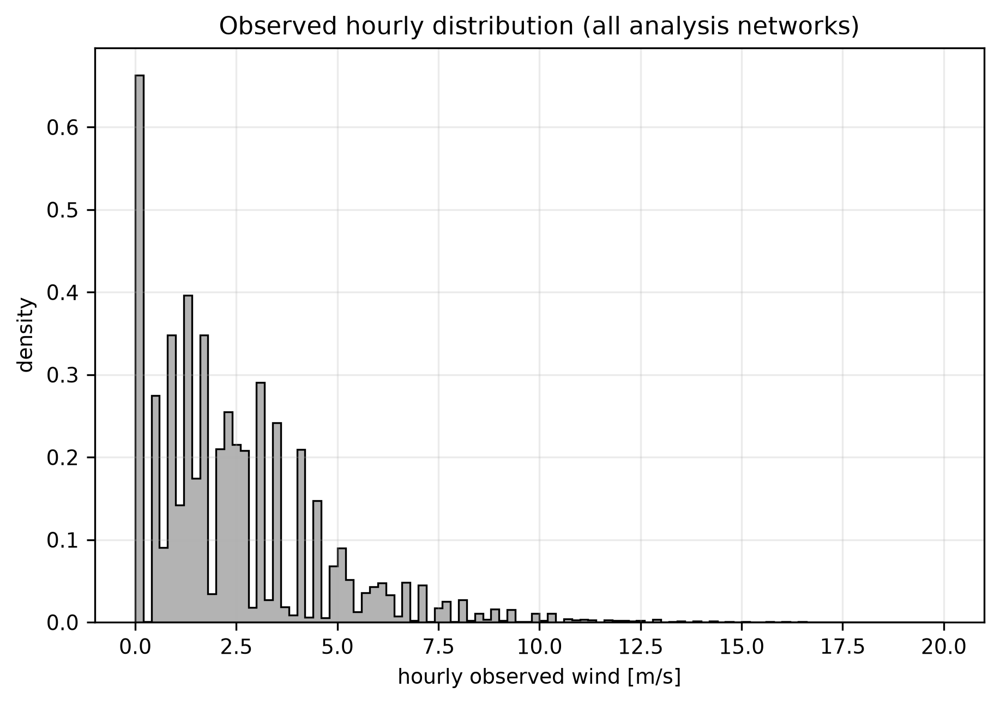

In [25]:
fig, ax = plt.subplots(figsize=(6, 4.2), constrained_layout=True)
ax.hist(vals, bins=np.linspace(0, 20, 101), histtype="stepfilled",
        density=True, color="0.7", edgecolor="k", lw=0.8)
ax.set_xlabel("hourly observed wind [m/s]")
ax.set_ylabel("density")
ax.set_title("Observed hourly distribution (all analysis networks)")
sub = vals[vals < 12]


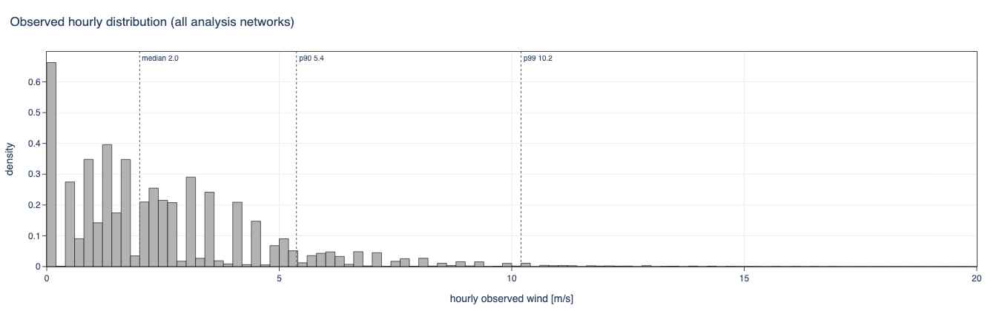

PosixPath('figures/html/dist_stations_hourly.html')

In [31]:
# Export: dist_stations_hourly
save_png(fig, "dist_stations_hourly")


def _plotly():
    # Binned in numpy: the raw hourly sample is far too large to embed.
    edges = np.linspace(0, 20, 101)
    dens, _ = np.histogram(vals, bins=edges, density=True)
    mid = 0.5 * (edges[1:] + edges[:-1])
    pf = go.Figure(go.Bar(
        x=mid, y=dens, width=np.diff(edges), marker=dict(
            color="#b3b3b3", line=dict(color="black", width=0.6)),
        name="stations",
        customdata=np.stack([edges[:-1], edges[1:]], axis=-1),
        hovertemplate="%{customdata[0]:.1f}–%{customdata[1]:.1f} m/s"
                      "<br>density %{y:.4f}<extra></extra>"))
    for qv, lab in ((np.median(vals), "median"), (np.quantile(vals, .9), "p90"),
                    (np.quantile(vals, .99), "p99")):
        pf.add_vline(x=qv, line=dict(color="#555", dash="dot", width=1),
                     annotation_text=f"{lab} {qv:.1f}",
                     annotation_position="top right",
                     annotation_font_size=10)
    pf.update_xaxes(title="hourly observed wind [m/s]", range=[0, 20])
    pf.update_yaxes(title="density")
    pf.update_layout(bargap=0, showlegend=False)
    return style(pf, "Observed hourly distribution (all analysis networks)",
                 height=420, width=700)


save_html(_plotly(), "dist_stations_hourly")


Text(0.5, 1.0, 'Airport stations only (n=207)')

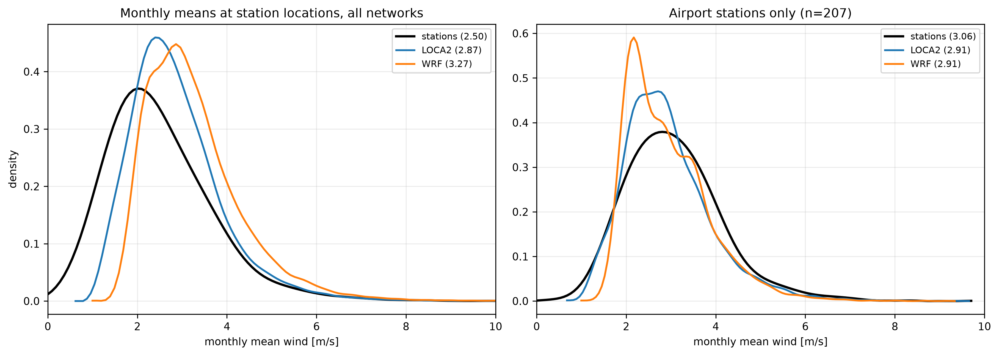

In [32]:
# Monthly means: the cadence at which products and observations are comparable.
# `stn`, `expo`, `net` and `smodel` were built in section 0; `smodel` has the
# WRF drivers already merged into one product.

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

# 1. All networks
o = stn["station"].values.ravel()
o = o[np.isfinite(o)]
pdf = fastKDE.pdf(o)
x_o, pdf_o = pdf.var0.values, pdf.values
ax[0].plot(x_o, pdf_o, lw=2, color="k", label=f"stations ({o.mean():.2f})")

for p, m in smodel.items():
    v = m.values.ravel()
    v = v[np.isfinite(v)]
    pdf = fastKDE.pdf(v)
    x_v, pdf_v = pdf.var0.values, pdf.values
    ax[0].plot(x_v, pdf_v, lw=1.6, color=COLOR[p],
               label=f"{LABEL[p]} ({v.mean():.2f})")

ax[0].set_xlabel("monthly mean wind [m/s]")
ax[0].set_ylabel("density")
ax[0].set_xlim(0, 10)  # Enforce the original 0-10 domain visually
ax[0].legend(fontsize=8)
ax[0].set_title("Monthly means at station locations, all networks")

# 2. Airports only: the exposure class closest to what a grid cell represents.
air = expo == "airport"
oa = stn["station"].isel(station_id=air).values.ravel()
oa = oa[np.isfinite(oa)]
pdf = fastKDE.pdf(oa)
x_oa, pdf_oa = pdf.var0.values, pdf.values
ax[1].plot(x_oa, pdf_oa, lw=2, color="k", label=f"stations ({oa.mean():.2f})")

for p, m in smodel.items():
    v = m.isel(station_id=air).values.ravel()
    v = v[np.isfinite(v)]
    pdf = fastKDE.pdf(v)
    x_v, pdf_v = pdf.var0.values, pdf.values
    ax[1].plot(x_v, pdf_v, lw=1.6, color=COLOR[p],
               label=f"{LABEL[p]} ({v.mean():.2f})")

ax[1].set_xlabel("monthly mean wind [m/s]")
ax[1].set_xlim(0, 10)  # Enforce the original 0-10 domain visually
ax[1].legend(fontsize=8)
ax[1].set_title(f"Airport stations only (n={int(air.sum())})")


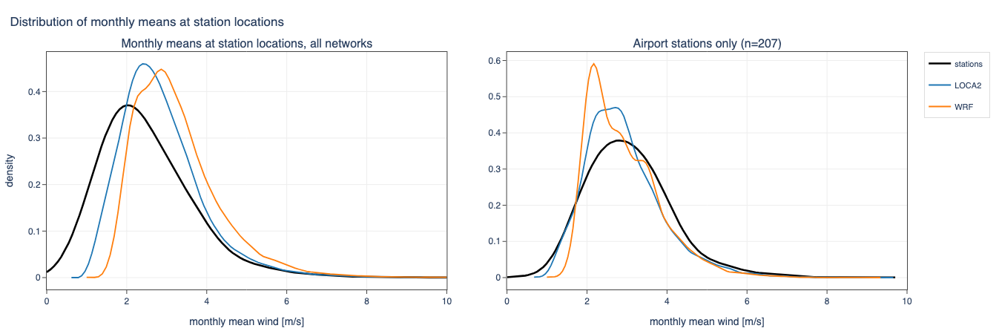

PosixPath('figures/html/dist_stations_monthly.html')

In [33]:
# Export: dist_stations_monthly
save_png(fig, "dist_stations_monthly")


def _plotly():
    def _kde(v):
        v = v[np.isfinite(v)]
        p = fastKDE.pdf(v)
        x, y = p.var0.values, p.values
        m = (x >= 0) & (x <= 12)
        return x[m], y[m], v.mean()

    air_ = expo == "airport"
    pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.07,
                       subplot_titles=(
                           "Monthly means at station locations, all networks",
                           f"Airport stations only (n={int(air_.sum())})"))
    for c, sel in ((1, slice(None)), (2, air_)):
        series = {"station": stn["station"].isel(station_id=sel)}
        series.update({p: m.isel(station_id=sel) for p, m in smodel.items()})
        for k, da in series.items():
            x, y, mu = _kde(da.values.ravel())
            pf.add_trace(go.Scatter(
                x=x, y=y, mode="lines", legendgroup=k, showlegend=c == 1,
                name=f"{LABEL[k]}",
                line=dict(color=PCOLOR[k], width=2.6 if k == "station" else 1.8),
                hovertemplate=f"<b>{LABEL[k]}</b> (mean {mu:.2f})"
                              "<br>%{x:.2f} m/s → %{y:.3f}<extra></extra>"),
                row=1, col=c)
    pf.update_xaxes(title="monthly mean wind [m/s]", range=[0, 10])
    pf.update_yaxes(title="density", row=1, col=1)
    return style(pf, "Distribution of monthly means at station locations",
                 height=450, hovermode="x unified")


save_html(_plotly(), "dist_stations_monthly")


In [34]:
# Distribution agreement by exposure class.
rows = []
for cls in ("airport", "vegetated", "irrigated", "mixed", "sea_level",
            "reference"):
    sel = expo == cls
    if sel.sum() < 10:
        continue
    o = stn["station"].isel(station_id=sel).values.ravel()
    o = o[np.isfinite(o)]
    row = {"exposure": cls, "n": int(sel.sum()), "obs mean": o.mean(),
           "obs p90": np.quantile(o, .90)}
    for g, m in smodel.items():
        v = m.isel(station_id=sel).values.ravel()
        v = v[np.isfinite(v)]
        row[f"{LABEL[g]} ratio"] = v.mean() / o.mean()
        # The 90th-percentile ratio beside the mean ratio: if they agree the
        # departure is a scale factor across the distribution; if p90 is larger
        # the tail is inflated more than the body, which no mean-based metric
        # can show.
        row[f"{LABEL[g]} p90r"] = np.quantile(v, .9) / np.quantile(o, .9)
    rows.append(row)
display(pd.DataFrame(rows).set_index("exposure").round(3))

,n,obs mean,obs p90,LOCA2 ratio,LOCA2 p90r,WRF ratio,WRF p90r
exposure,,,,,,,
airport,207,3.056,4.419,0.954,0.946,0.953,0.935
irrigated,173,2.006,2.825,1.428,1.394,1.472,1.431
mixed,20,2.131,3.289,1.399,1.341,1.778,1.867


### Findings

**The observed hourly distribution is not remotely Gaussian, and two features of
it are reporting convention rather than wind.**

Pooled over 108 million valid hourly observations: mean 2.47 m/s, median 2.00,
p90 5.37, p99 10.20. **13.2 % of values are exactly zero** and **38.3 % fall
below 1.5 m/s**. The zero spike is the ASOS calm floor that reports below roughly
3 kt are recorded as 0 and no model can reproduce that. Every model/observation
ratio in this notebook is therefore slightly generous to the model.

**Station quality screening removed 338 of 1,207 stations**, and the breakdown
matters for how the archive is described:

| reason | n |
|---|---|
| record < 60 months | 292 |
| < 20 distinct values (stuck sensor) | 98 |
| observed mean < 0.5 m/s | 46 |
| excluded prefix `RAWS_TR` | 73 |

869 stations retained. 

### 2.1 Daily distributions against observations

Monthly means are far narrower than a real wind distribution, so §2's overlap
says less than it appears. Daily values get closer, and the archive supports
them for every product.

The products are re-sampled here from the **daily** contexts at station
locations, `station_vs_models` is monthly. Every source is reduced to the same
sample: only days where both the observation and the model exist, and only days
with at least 18 hourly reports.

This also supports the standard engineering description of a wind climate —
Weibull shape `k` and scale `A` — and hence power density, referenced to the
observations rather than to a model.

In [35]:
# Daily values at station locations, built by build_metrics.py --stages
# station_daily. One pass over the hourly archive, computed once.
sd = read("station_daily").compute()
obs_d = sd["obs_mean"]
at_stn = merge_wrf({k.replace("model_", ""): sd[k] for k in sd.data_vars
                    if k.startswith("model_")})
if "era5" in sd:
    at_stn["era5"] = sd["era5"]
expo_d = np.array([str(e) for e in sd.exposure.values])
sids_d = [str(s) for s in sd.station_id.values]
print(f"{sd.sizes['station_id']} stations x {sd.sizes['time']} days")
print(f"sources: {list(at_stn)}")
print(
    f"guard: >= {sd.attrs.get('min_hours_per_day', '?')} hourly reports per day")

869 stations x 12784 days
sources: ['loca2', 'wrf', 'era5']
guard: >= 18 hourly reports per day


In [36]:
def pooled(source, cls=None):
    """Flattened daily values, restricted to days where BOTH sides exist.

    Sharing the sample matters: comparing a model's full record against an
    observation's gappy one would compare different weather, not different
    models.
    """
    da = obs_d if source == "station" else at_stn[source]
    o, m = xr.align(obs_d, da, join="inner")
    sel = (np.ones(o.sizes["station_id"], bool) if cls is None
           else np.isin([str(s) for s in o.station_id.values],
                        [sids_d[i] for i in np.where(expo_d == cls)[0]]))
    src = (o if source == "station" else m).isel(station_id=np.where(sel)[0])
    both = (np.isfinite(o.isel(station_id=np.where(sel)[0]).values.ravel())
            & np.isfinite(m.isel(station_id=np.where(sel)[0]).values.ravel()))
    return src.values.ravel()[both]


SOURCES = ["station"] + [k for k in at_stn]
daily = {s: pooled(s) for s in SOURCES}
for k, v in daily.items():
    print(f"{LABEL[k]:<10} n={v.size:>9,}  mean {v.mean():.2f}  "
          f"p50 {np.median(v):.2f}  p90 {np.quantile(v, .9):.2f}  "
          f"p99 {np.quantile(v, .99):.2f}  max {v.max():.1f}")

stations   n=4,302,685  mean 2.43  p50 2.06  p90 4.41  p99 8.31  max 65.7
LOCA2      n=4,121,241  mean 2.94  p50 2.59  p90 4.82  p99 7.92  max 18.4
WRF        n=4,196,189  mean 3.40  p50 3.11  p90 5.05  p99 7.71  max 17.7
ERA5       n=4,121,241  mean 2.16  p50 1.91  p90 3.43  p99 5.73  max 13.0


In [37]:
def kde(v, smooth=5, floor=1e-6):
    """Smoothed density on a common footing for every source.

    Clipped at zero because a KDE will happily put mass at negative wind speed,
    and the tail panel plots density on a log axis where that mass would show
    as a spurious branch. `floor` trims the numerical noise that a KDE leaves
    far out in the tail -- without it the log panel is dominated by values that
    are artefacts of the kernel rather than data.
    """
    pdf = fastKDE.pdf(v.clip(min=0))
    x = pdf.var0.values
    y = pdf.rolling(var0=smooth).mean().values if smooth else pdf.values
    m = np.isfinite(y) & (y > floor)
    return x[m], y[m]


def dist_panels(pool, title, fname, q):
    """Linear density, log density and Q-Q -- the three views that separate
    a scale error from a shape error.

    The log panel is not decoration: the body of the distribution and its tail
    answer different questions, and a product can match one while missing the
    other. Only the tail matters for fire weather and design loads.
    """
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
    for k, v in pool.items():
        lw = 2.4 if k == "station" else 1.5
        x, y = kde(v)
        for a in (ax[0], ax[1]):
            a.plot(x, y, lw=lw, color=COLOR[k],
                   label=f"{LABEL[k]} ({v.mean():.2f})" if a is ax[0] else None)

    ax[0].set_xlabel("daily mean wind [m/s]")
    ax[0].set_ylabel("density")
    ax[0].legend(fontsize=8)
    ax[0].set_xlim(0, 10)
    ax[0].set_title(f"Daily distribution — {title}")
    ax[1].set_yscale("log")
    ax[1].set_xlim(0, 20)
    ax[1].set_xlabel("daily mean wind [m/s]")
    ax[1].set_title("Same, log density — the tail")

    # Q-Q against OBSERVATIONS. A straight line through the origin means the
    # product's departure is a pure scale factor; curvature locates which part
    # of the distribution is wrong.
    oq = np.quantile(pool["station"], q)
    for k, v in pool.items():
        if k == "station":
            continue
        ax[2].plot(oq, np.quantile(v, q), color=COLOR[k],
                   lw=1.8, label=LABEL[k])
    lim = [0, oq.max() * 1.4]
    ax[2].plot(lim, lim, "k--", lw=1.2)
    ax[2].set_xlabel("observed quantile [m/s]")
    ax[2].set_ylabel("modelled quantile")
    ax[2].legend(fontsize=8)
    ax[2].set_title(f"Q-Q — {title}")
    
.stem)
    return fig


SyntaxError: unmatched ')' (1393420394.py, line 59)

Check if stations and models are looking at the same times (not only space)

In [ ]:
q = np.linspace(0.005, 0.995, 199)
fig_daily_all = dist_panels(daily, "all analysis stations",
                            "dist_daily_stations.png", q)

# Airports separately: the exposure class closest to what a grid cell average
# represents, and so the one where agreement is actually expected. Curvature
# here is a model finding; curvature in the pooled panel above may only be a
# siting mixture.
n_air = int((expo_d == "airport").sum())
if n_air >= 10:
    air = {s: pooled(s, "airport") for s in SOURCES}
    fig_daily_air = dist_panels(air, f"airport stations (n={n_air})",
                                "dist_daily_airports.png", q)
else:
    air = {}
    fig_daily_air = None
    print(f"only {n_air} airport stations -- skipping the airport panels")

In [ ]:
def plotly_dist_panels(pool, title, q):
    """Interactive twin of dist_panels: linear density, log density, Q-Q.

    LAYOUT. Two rows: the two density panels side by side above, the Q-Q centred
    below. Built on a FOUR-column grid with column spans rather than a 2x2 with
    an empty cell -- spanning cols 2-3 puts the Q-Q's centre exactly on 0.5,
    where a 2x2 would leave it hard against one side.

    A LEGEND PER PANEL rather than one shared. A single legend eats ~15% of the
    width of a figure that is already tight, and the Q-Q panel has a DIFFERENT
    trace set -- no observations, since they are the x-axis -- which one legend
    cannot express. Readers otherwise wonder where the black line went.

    Needs plotly >= 5.15 for multiple legends.
    """
    HS, VS = 0.07, 0.13
    pf = make_subplots(
        rows=2, cols=4, horizontal_spacing=HS, vertical_spacing=VS,
        specs=[[{"colspan": 2}, None, {"colspan": 2}, None],
               [None, {"colspan": 2}, None, None]],
        subplot_titles=(f"Daily distribution — {title}",
                        "Same, log density — the tail",
                        f"Q-Q — {title}"))

    # (row, col) of each panel in the 4-column grid, and the legend it feeds.
    PANEL = {"density": (1, 1), "logdens": (1, 3), "qq": (2, 2)}
    LEG = {"density": "legend", "logdens": "legend2", "qq": "legend3"}

    for k, v in pool.items():
        x, y = kde(v)
        w = 2.8 if k == "station" else 1.8
        for name in ("density", "logdens"):
            r, c = PANEL[name]
            pf.add_trace(go.Scatter(
                x=x, y=y, mode="lines", name=LABEL[k], legendgroup=k,
                legend=LEG[name], showlegend=True,
                line=dict(color=PCOLOR[k], width=w),
                hovertemplate=f"<b>{LABEL[k]}</b> (mean {v.mean():.2f})"
                              "<br>%{x:.2f} m/s → %{y:.3g}<extra></extra>"),
                row=r, col=c)

    oq = np.quantile(pool["station"], q)
    r, c = PANEL["qq"]
    for k, v in pool.items():
        if k == "station":
            continue
        pf.add_trace(go.Scatter(
            x=oq, y=np.quantile(v, q), mode="lines", name=LABEL[k],
            legendgroup=k, legend=LEG["qq"], showlegend=True,
            line=dict(color=PCOLOR[k], width=2), customdata=q * 100,
            hovertemplate=f"<b>{LABEL[k]}</b><br>p%{{customdata:.1f}}: "
                          "obs %{x:.2f} → model %{y:.2f} m/s<extra></extra>"),
            row=r, col=c)
    ref_line(pf, 0, oq.max() * 1.4, row=r, col=c)

    pf.update_xaxes(title="daily mean wind [m/s]", range=[0, 10], row=1, col=1)
    pf.update_xaxes(title="daily mean wind [m/s]", range=[0, 20], row=1, col=3)
    pf.update_yaxes(title="density", row=1, col=1)
    pf.update_yaxes(type="log", exponentformat="power", row=1, col=3)
    pf.update_xaxes(title="observed quantile [m/s]", row=2, col=2)
    pf.update_yaxes(title="modelled quantile [m/s]", row=2, col=2)

    # Legends read from the subplot domains rather than guessed coordinates, so
    # changing HS or the column spans moves them correctly.
    dom = lambda ax: pf.layout[ax].domain
    box = dict(bgcolor="rgba(255,255,255,0.78)",
               bordercolor="rgba(0,0,0,0.15)", borderwidth=1,
               font=dict(size=10), itemsizing="constant")
    pf.update_layout(
        # Both density panels fall away to the right, leaving the top-right
        # corner empty; the Q-Q rises to the top-right, so its legend goes
        # bottom-right.
        legend=dict(x=dom("xaxis")[1] - 0.005, y=dom("yaxis")[1] - 0.01,
                    xanchor="right", yanchor="top", **box),
        legend2=dict(x=dom("xaxis2")[1] - 0.005, y=dom("yaxis2")[1] - 0.01,
                     xanchor="right", yanchor="top", **box),
        legend3=dict(x=dom("xaxis3")[1] - 0.005, y=dom("yaxis3")[0] + 0.01,
                     xanchor="right", yanchor="bottom", **box),
    )
    return style(pf, width=750, height=700)

In [ ]:
save_html(plotly_dist_panels(daily, "all analysis stations", q),
          "dist_daily_stations")
if air:
    save_html(plotly_dist_panels(air, f"airport stations (n={n_air})", q),
              "dist_daily_airports")

In [ ]:
# Weibull shape and scale, the standard description of a wind climate,
# referenced to the observations.
#
# Moment estimators rather than a fit: k = (sigma/mu)^-1.086 is the accepted
# engineering approximation and needs no optimiser, so this stays reproducible
# without a scipy version dependency.
from math import gamma


def weibull_params(v):
    mu, sd = v.mean(), v.std()
    k = (sd / mu) ** -1.086
    return k, mu / gamma(1 + 1 / k)


def weibull_table(pool, label):
    rows = []
    for k_, v in pool.items():
        sh, sc = weibull_params(v)
        # Mean power density per unit area, rho = 1.225. Proportional to
        # A^3 * Gamma(1 + 3/k) -- power goes as the CUBE of speed, which is why
        # a modest speed error is a large power error.
        rows.append({"source": LABEL[k_], "mean": v.mean(), "k (shape)": sh,
                     "A (scale)": sc,
                     "power W/m2": 0.5 * 1.225 * sc ** 3 * gamma(1 + 3 / sh)})
    df = pd.DataFrame(rows).set_index("source")
    base = LABEL["station"]
    df["speed ratio"] = df["mean"] / df.loc[base, "mean"]
    df["power ratio"] = df["power W/m2"] / df.loc[base, "power W/m2"]
    print(f"\n--- {label} (referenced to observations) ---")
    display(df.round(3))
    return df


if not daily:
    raise SystemExit(
        "no daily contexts -- run build_metrics.py --stages daily")
df_all = weibull_table(daily, "all analysis stations")
if (expo_d == "airport").sum() >= 10:
    df_air = weibull_table(air, "airport stations")

print("\nPower ratio tracks speed ratio CUBED where the SHAPE matches;")
print("a gap between them means k differs, not just A:")
for s in df_all.index:
    if s == LABEL["station"]:
        continue
    print(f"  {s:<10} speed^3 = {df_all.loc[s, 'speed ratio']**3:.2f}  "
          f"actual power ratio = {df_all.loc[s, 'power ratio']:.2f}")

### Findings

**The shape parameter** Weibull `k` describes the balance
between calm and windy days; lower `k` means a broader distribution.

| source | mean | k (shape) | A (scale) | power W/m² |
|---|---|---|---|---|
| **stations** | 2.43 | **1.51** | 2.69 | 23.7 |
| LOCA2 | 2.94 | 2.18 | 3.32 | 27.4 |
| WRF | 3.40 | 2.92 | 3.81 | 34.3 |
| ERA5 | 2.16 | 2.32 | 2.44 | 10.3 |

Observed `k` is **1.51**; the products give **2.18 and 2.92**. Both show 
too few calm days *and* too few windy ones. 

**At airports, the products UNDER-predict power** 
compared to what the observed wind, because it lacks the broad tails
that carry the energy. 

| source | speed ratio | power ratio |
|---|---|---|
| LOCA2 | 0.977 | **0.812** |
| WRF | 1.077 | **0.875** |
| ERA5 | 0.757 | 0.355 |

---
## 3. CONUS404: do independent km-scale models agree?

Stations answer "is it right where we measured?" but cannot cover the ocean and
are sparse in high terrain. CONUS404 answers a complementary question with full
spatial coverage: **does an independently built km-scale model reach the same
field?**

It is 4 km WRF driven by ERA5, produced by NCAR and USGS, same resolution class
and same driver as WRF-ERA5, differing in configuration, land surface and
physics. If the AE products carried a configuration defect, CONUS404 would not
share it.

In [ ]:
if have("native_c404_vs_ae"):
    nat = read("native_c404_vs_ae")
    stores = [str(x) for x in nat["product"].values]

    # Merged to products. The ratio FIELDS are averaged before the median is
    # taken, not the medians averaged -- the median of an average is the honest
    # summary of the merged product, while an average of medians is a summary
    # of a thing that was never computed.
    rows = []
    for g in GROUPS:
        want = WRF_DRIVERS if g == "wrf" else [g]
        idx = [i for i, s in enumerate(stores) if s in want]
        if not idx:
            continue
        r = nat.ratio.isel(product=idx).mean("product")
        rows.append({"product": LABEL[g],
                     "median ratio": float(np.nanmedian(r.values)),
                     "n_cells": int(r.notnull().sum()),
                     "n_drivers": len(idx)})
    display(pd.DataFrame(rows).set_index("product").round(3))
    print(nat.attrs.get("reference", ""))
else:
    print("native comparison absent -- run --stages conus404_native")

### Findings

**On CONUS404's own 4 km grid, with no coarse field involved, WRF and CONUS404
agree to 2 %.**

| product | median ratio | n_cells |
|---|---|---|
| **WRF** | **1.020** | 225,848 |
| LOCA2 | 0.902 | 49,773 |

**WRF at 1.020.** Two
independently built km-scale models. Different institutions, different
configurations, different land-surface and physics choices, produce
statistically similar wind field.

**LOCA2 at 0.902 sits 10 % below an independent km-scale model** while sitting
29 % *above* ERA5 (§8). Prbably due to the fact that
statistical downscaling inherits the smoother
field it was trained to reproduce and does not manufacture the acceleration a
dynamical model generates.

**Taken with §1, the picture is consistent.** At airports both products are
right. Away from airports LOCA2 is lower than WRF; against an unobstructed
km-scale comparator LOCA2 is lower than WRF. 

---
## 4. Between products, at station locations

Every product divided by the **observation at the same point**, so the columns
are directly comparable and none depends on a reanalysis.



In [ ]:
# Between products, at station locations. No gridded reference involved.
#
# Two products, not three: the WRF drivers were merged in section 0. They are
# one model configuration under different boundary conditions, so reporting them
# separately would give the same model two rows.
rows = []
for g, m in smodel.items():
    r = (m.mean("time").values / obs_mean)
    row = {"product": LABEL[g], "all": float(np.nanmedian(r))}
    for cls in ("airport", "vegetated", "irrigated"):
        sel = expo == cls
        if sel.sum() >= 10:
            row[cls] = float(np.nanmedian(r[sel]))
    rows.append(row)
display(pd.DataFrame(rows).set_index("product").round(3))

# The drivers ARE kept separate for one check: are they interchangeable? That
# is the claim licensing the merge everywhere else, so it is tested rather than
# assumed. It is also the one place same-timestep skill could differ, since only
# the reanalysis-driven run downscales the observed atmosphere.
have_both = [d for d in WRF_DRIVERS if f"model_{d}" in stn]
if len(have_both) == 2:
    a = stn[f"model_{have_both[0]}"].mean("time").values
    b = stn[f"model_{have_both[1]}"].mean("time").values
    d = (a - b) / b * 100
    print(f"\n{LABEL[have_both[0]]} vs {LABEL[have_both[1]]} at stations:")
    print(f"  median {np.nanmedian(d):+.2f}%, IQR {np.nanpercentile(d, 25):+.2f} "
          f"to {np.nanpercentile(d, 75):+.2f}%")
    print("  A systematic offset would mean the driver changes the CLIMATE and "
          "the merge is unjustified;\n  scatter about zero means it changes only "
          "the weather, which is expected.")

In [ ]:
# Product against product at each station, with observations as the origin.
fig, ax = plt.subplots(figsize=(6, 4.2), constrained_layout=True)
panels = [("loca2", "wrf", "products")]
# for j, (a_, b_, what) in enumerate(panels):
a_, b_, what = panels[0]
getx = smodel.get(a_) if a_ in smodel else stn.get(f"model_{a_}")
gety = smodel.get(b_) if b_ in smodel else stn.get(f"model_{b_}")
# if getx is None or gety is None:
#     ax[j].set_visible(False)
#     continue
xa = (getx.mean("time").values / obs_mean)
yb = (gety.mean("time").values / obs_mean)
for cls in pd.unique(expo):
    sel = expo == cls
    # if sel.sum() < 10:
    #     continue
    ax.scatter(xa[sel], yb[sel], s=16, alpha=0.6, label=cls)
hi = np.nanpercentile(np.r_[xa, yb], 99)
lim = [0, hi * 1.05]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.axhline(1, color="0.6", lw=0.8)
ax.axvline(1, color="0.6", lw=0.8)
ax.set_xlabel(f"{LABEL[a_]} / observation")
ax.set_ylabel(f"{LABEL[b_]} / observation")
ax.set_title(f"{what}: {LABEL[a_]} vs {LABEL[b_]}")
ax.legend(fontsize=8)


In [ ]:
# Export: between_products_stations
save_png(fig, "between_products_stations")


def _plotly():
    a_, b_ = "loca2", "wrf"
    xa_ = smodel[a_].mean("time").values / obs_mean
    yb_ = smodel[b_].mean("time").values / obs_mean
    pf = go.Figure()
    for i, cls in enumerate(pd.unique(expo)):
        idx = np.where(expo == cls)[0]
        cd, tmpl = station_hover(idx)
        pf.add_trace(go.Scatter(
            x=xa_[idx], y=yb_[idx], mode="markers", name=cls,
            marker=dict(size=7, opacity=0.7, color=PCAT[i % len(PCAT)],
                        line=dict(color="white", width=0.4)),
            customdata=cd,
            hovertemplate=tmpl + f"<br>{LABEL[a_]}/obs %{{x:.2f}}"
                                 f"<br>{LABEL[b_]}/obs %{{y:.2f}}<extra></extra>"))
    hi = np.nanpercentile(np.r_[xa_, yb_], 99) * 1.05
    ref_line(pf, 0, hi)
    pf.add_hline(y=1, line=dict(color="#999", width=0.8))
    pf.add_vline(x=1, line=dict(color="#999", width=0.8))
    pf.update_xaxes(title=f"{LABEL[a_]} / observation", range=[0, hi])
    pf.update_yaxes(title=f"{LABEL[b_]} / observation", range=[0, hi],
                    scaleanchor="x", scaleratio=1)
    pf.update_layout(legend_title_text="exposure")
    return style(pf, f"products: {LABEL[a_]} vs {LABEL[b_]}",
                 height=600, width=720)


save_html(_plotly(), "between_products_stations")


### Findings

**The two WRF drivers are interchangeable, which is what licenses treating them
as one product.**

At stations: median difference **+0.60 %**, IQR **−0.76 % to +1.65 %**. Centred
on zero with a spread of a couple of percent — the driver changes the weather,
not the climate. §9.5 confirms it on the grid: the reanalysis-driven member sits
inside the GCM-driven range.

**The products are identical where it can be measured and divergent where it
cannot.**

| | all stations | airport | irrigated |
|---|---|---|---|
| LOCA2 | 1.166 | **0.996** | 1.403 |
| WRF | 1.354 | **0.995** | 1.488 |

At airports — the only unobstructed class — they agree to 0.001. Everywhere else
they differ by 8–19 %, and those classes are confounded by shelter.

**The pooled column is therefore the least useful number in the table.** LOCA2
1.166 against WRF 1.354 looks like a substantive difference between products,
but it is largely a difference in how each responds to stations that are
sheltered by amounts neither model knows. §4 gets at the same question without
that confound, and reverses the apparent ranking.

---
## 5. Seasonal structure, against observations

Does agreement have a seasonal cycle? A flat line means one scale factor
describes the whole year and the difference is structural. A summer or winter
maximum points at a seasonally varying mechanism — stability, or how the storm
track is represented.

The ratio is formed **per station**, comparing each site's monthly climatology
to its own model counterpart, so the footprint and siting mismatch largely
divides out and what remains is seasonal.

In [ ]:
# Seasonal cycle of agreement, at station locations.
#
# Per-station monthly climatology on both sides, then the ratio -- so each
# station is compared to itself and the shelter mismatch largely divides out.
o_clim = stn["station"].groupby("time.month").mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for g, m in smodel.items():
    m_clim = m.groupby("time.month").mean()
    # Force (month, station): groupby does not guarantee dim order, and a
    # transposed array would silently plot 12 months against N stations.
    r = (m_clim / o_clim).transpose("month", "station_id").values
    ax[0].plot(range(1, 13), np.nanmedian(r, axis=1), "o-",
               color=COLOR[g], lw=1.6, label=LABEL[g])
    air = expo == "airport"
    if air.sum() >= 10:
        ax[1].plot(range(1, 13), np.nanmedian(r[:, air], axis=1), "o-",
                   color=COLOR[g], lw=1.6, label=LABEL[g])

oc = np.nanmedian(o_clim.transpose("month", "station_id").values, axis=1)
for a in ax:
    a.axhline(1, color="k", lw=1, ls="--")
    a.set_xticks(range(1, 13))
    a.set_xlabel("month")
    a.set_ylabel("model / observation")
    a.legend(fontsize=8)
ax[0].set_title("Seasonal cycle of agreement, all stations")
ax[1].set_title("Airport stations only — the unobstructed class")
tw = ax[0].twinx()
tw.plot(range(1, 13), oc, color="0.5", lw=1, ls=":")
tw.set_ylabel("observed wind [m/s]", color="0.5")

rows = []
air = expo == "airport"
for g, m in smodel.items():
    r = (m.groupby("time.month").mean() / o_clim
         ).transpose("month", "station_id").values
    for label, sel in (("all", slice(None)), ("airport", air)):
        if label == "airport" and air.sum() < 10:
            continue
        med = np.nanmedian(r[:, sel], axis=1)
        rows.append({"product": LABEL[g], "stations": label,
                     "DJF": np.nanmean(med[[11, 0, 1]]),
                     "MAM": np.nanmean(med[2:5]), "JJA": np.nanmean(med[5:8]),
                     "SON": np.nanmean(med[8:11]),
                     "max-min": float(med.max() - med.min())})
display(pd.DataFrame(rows).set_index(["product", "stations"]).round(3))


In [ ]:
# Export: seasonal_stations
save_png(fig, "seasonal_stations")


def _plotly():
    oc_ = stn["station"].groupby("time.month").mean()
    air_ = expo == "airport"
    pf = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.16,
        specs=[[{"secondary_y": True}, {"secondary_y": False}]],
        subplot_titles=("Seasonal cycle of agreement, all stations",
                        "Airport stations only — the unobstructed class"))
    for g, m in smodel.items():
        r_ = (m.groupby("time.month").mean() / oc_
              ).transpose("month", "station_id").values
        panels = [(1, slice(None))] + ([(2, air_)] if air_.sum() >= 10 else [])
        for c, sel in panels:
            pf.add_trace(go.Scatter(
                x=MONTHS, y=np.nanmedian(r_[:, sel], axis=1),
                mode="lines+markers", name=LABEL[g], legendgroup=g,
                showlegend=c == 1, line=dict(color=PCOLOR[g], width=2),
                marker=dict(size=7),
                hovertemplate=f"{LABEL[g]}: %{{y:.3f}}<extra></extra>"),
                row=1, col=c, **({"secondary_y": False} if c == 1 else {}))
    ocv = np.nanmedian(oc_.transpose("month", "station_id").values, axis=1)
    pf.add_trace(go.Scatter(
        x=MONTHS, y=ocv, mode="lines", name="observed wind",
        line=dict(color="#888", dash="dot", width=1.4),
        hovertemplate="observed: %{y:.2f} m/s<extra></extra>"),
        row=1, col=1, secondary_y=True)
    for c in (1, 2):
        pf.add_hline(y=1, line=dict(color="black", dash="dash", width=1),
                     row=1, col=c)
        pf.update_xaxes(title="month", row=1, col=c)
    pf.update_yaxes(title="model / observation", row=1, col=1,
                    secondary_y=False)
    pf.update_yaxes(title="model / observation", row=1, col=2)
    pf.update_yaxes(title="observed wind [m/s]", row=1, col=1,
                    secondary_y=True, showgrid=False,
                    title_font_color="#888", tickfont_color="#888")
    return style(pf, height=350, hovermode="x unified")


save_html(_plotly(), "seasonal_stations")


### 5.1 Regional structure

Agreement is not uniform across the domain, and the pooled numbers in §1 average
over places whose wind climates have nothing in common. This splits the same
comparison by California climate region.

Two things to hold in mind while reading it:

**The `(air)` columns are the ones that mean something.** Which networks operate
where varies strongly by region — RAWS dominates the Sierra, CIMIS the Central
Valley, ASOSAWOS the coastal basins — so a regional difference in the pooled
column may only be a difference in *network mix*, and therefore in shelter,
rather than in model skill. Restricting to airports removes that.

**The regions are approximate boxes.** They were validated against twenty known
sites, but boxes drawn from coordinates go wrong at edges. The map is there to
be checked before the table is trusted.

In [38]:
# California climate regions, from station coordinates and elevation.
#
# APPROXIMATE BOXES, validated against 20 known sites and meant to be adjusted.
# They are ordered and first-match-wins: independent overlapping tests would
# assign a Sierra foothill station to whichever box happened to be checked last.
#
# Regions rather than latitude bands, because the wind climate here is organised
# by terrain and marine influence rather than by latitude -- Monterey and Fresno
# share a latitude and nothing else.
CA_REGIONS = [
    ("North Coast", lambda la, lo, z: (la >= 38.5) & (lo <= -122.3)),
    ("Bay & Delta", lambda la, lo, z: (la >= 36.9) & (la < 38.7)
     & (lo >= -122.8) & (lo <= -121.2)),
    ("Central Coast", lambda la, lo, z: (la >= 34.9) & (la < 37.0)
     & (lo <= -120.2)),
    ("South Coast", lambda la, lo, z: (la < 34.9) & (lo >= -120.7)
     & (lo <= -117.0)),
    ("Sierra Nevada", lambda la, lo, z: (z >= 900) & (la >= 35.3)
     & (la <= 40.5) & (lo >= -121.5)
     & (lo <= -117.8)),
    ("Central Valley", lambda la, lo, z: (la >= 35.0) & (la <= 41.0)
     & (lo >= -122.6) & (lo <= -118.6)
     & (z < 400)),
    ("Mojave/Sonoran", lambda la, lo, z: (la < 36.6) & (lo > -117.8)),
    ("Northeast", lambda la, lo, z: (la >= 40.0) & (lo > -122.0)),
]
MIN_REGION_N = 15          # below this a median is a handful of stations


def region_of(lat, lon, elev):
    lat, lon = np.asarray(lat, float), np.asarray(lon, float)
    z = np.asarray(elev, float)
    z = np.where(np.isfinite(z), z, 0.0)
    out = np.full(lat.shape, "other", dtype=object)
    for name, test in CA_REGIONS:
        m = (out == "other") & test(lat, lon, z)
        out[m] = name
    return out


# Elevation from the retrieved stores, not stations.csv, whose elevation column
# mixes units between networks -- see section 3.
try:
    _e = L.station_elevation(ROOT, verbose=False)
    _lut = {str(s): float(v) for s, v in zip(_e.station_id.values, _e.values)}
    z_stn = np.array([_lut.get(s, np.nan) for s in sids])
except Exception as _err:
    print(f"no station elevation ({type(_err).__name__}); the Sierra and "
          "Central Valley boxes both depend on it and will be unreliable")
    z_stn = np.full(len(sids), np.nan)

region = region_of(slat, slon, z_stn)
display(pd.DataFrame({"region": region, "exposure": expo})
        .value_counts().unstack(fill_value=0))

exposure,airport,irrigated,mixed,ridge
region,,,,
Bay & Delta,25,40,1,27
Central Coast,8,20,0,15
Central Valley,25,37,8,19
Mojave/Sonoran,46,30,0,74
North Coast,12,5,0,77
Northeast,10,4,0,74
Sierra Nevada,11,4,9,73
South Coast,60,30,0,72
other,10,3,2,38


In [39]:
rows = []
for reg in [r for r, _ in CA_REGIONS] + ["other"]:
    sel = region == reg
    if sel.sum() < MIN_REGION_N:
        continue
    row = {"region": reg, "n": int(sel.sum()),
           "obs mean": float(np.nanmedian(obs_mean[sel])),
           "n_air": int((sel & (expo == "airport")).sum())}
    for g, m in smodel.items():
        r = (m.mean("time").values / obs_mean)[sel]
        row[LABEL[g]] = float(np.nanmedian(r[np.isfinite(r)]))
    # Airports only. THIS is the column to read: the pooled one mixes exposure
    # classes, and which networks operate where varies by region -- RAWS
    # dominates the Sierra, CIMIS the Central Valley -- so a regional difference
    # there may only be a difference in network mix rather than in model skill.
    air = sel & (expo == "airport")
    if air.sum() >= 8:
        for g, m in smodel.items():
            r = (m.mean("time").values / obs_mean)[air]
            row[f"{LABEL[g]} (air)"] = float(np.nanmedian(r[np.isfinite(r)]))
    rows.append(row)
display(pd.DataFrame(rows).set_index("region").round(3))

,n,obs mean,n_air,LOCA2,WRF,LOCA2 (air),WRF (air)
region,,,,,,,
North Coast,94,2.011,12,1.198,1.393,1.122,1.050
Bay & Delta,93,2.363,25,1.219,1.155,1.046,0.811
Central Coast,43,2.405,8,1.214,1.338,0.983,0.917
South Coast,162,2.279,60,1.155,1.202,1.052,0.952
Sierra Nevada,97,2.209,11,1.274,1.650,1.018,1.106
Central Valley,89,2.177,25,1.163,1.316,0.996,1.064
Mojave/Sonoran,150,2.588,46,1.185,1.459,0.873,1.020
Northeast,88,2.444,10,1.108,1.427,0.827,1.110
other,53,2.715,10,1.069,1.347,0.981,1.198


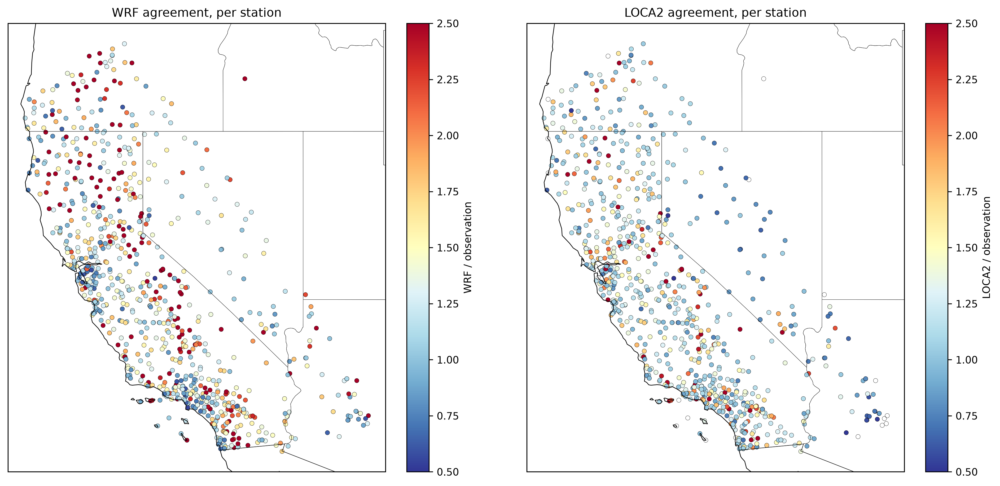

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True, subplot_kw={
                       "projection": ccrs.PlateCarree()})

g0 = "wrf" if "wrf" in smodel else list(smodel)[0]
r0 = (smodel[g0].mean("time").values / obs_mean)
sc = ax[0].scatter(slon, slat, c=np.clip(r0, 0.5, 2.5), s=16, cmap="RdYlBu_r",
                   vmin=0.5, vmax=2.5, edgecolor="k", lw=0.2)
ax[0].set_aspect(1 / np.cos(np.deg2rad(37)))
ax[1].set_xlabel("longitude")
plt.colorbar(sc, ax=ax[0], label=f"{LABEL[g0]} / observation")
ax[0].set_title(f"{LABEL[g0]} agreement, per station")

g1 = "loca2" if "loca2" in smodel else list(smodel)[0]
r1 = (smodel[g1].mean("time").values / obs_mean)
sc = ax[1].scatter(slon, slat, c=np.clip(r1, 0.5, 2.5), s=16, cmap="RdYlBu_r",
                   vmin=0.5, vmax=2.5, edgecolor="k", lw=0.2)
ax[1].set_aspect(1 / np.cos(np.deg2rad(37)))
ax[1].set_xlabel("longitude")
plt.colorbar(sc, ax=ax[1], label=f"{LABEL[g1]} / observation")
ax[1].set_title(f"{LABEL[g1]} agreement, per station")


for a in ax:
    a.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.6, zorder=3)
    a.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, zorder=3)
    a.add_feature(cfeature.STATES.with_scale("50m"), lw=0.2)


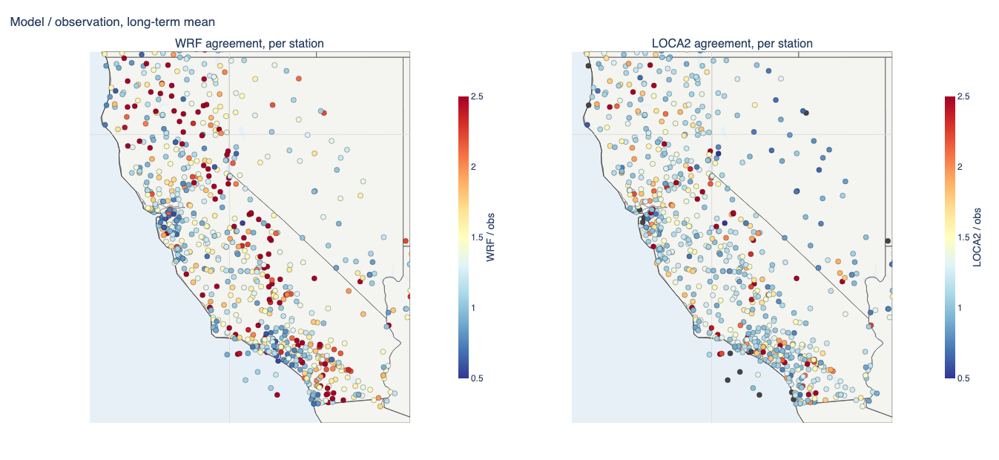

PosixPath('figures/html/station_agreement_maps.html')

In [41]:
# Export: station_agreement_maps  (was saved as regional_stations.png, which
# cells below overwrite -- so it gets its own name here)
save_png(fig, "station_agreement_maps")

def _geo_layout(pf, n):
    """California basemap for n side-by-side geo subplots."""
    for i in range(1, n + 1):
        pf.update_layout(**{f"geo{i if i > 1 else ''}": dict(
            scope="north america",   # the world basemap has no US states
            projection_type="mercator", resolution=50,
            lonaxis_range=[-124.8, -113.8], lataxis_range=[32.2, 42.3],
            showland=True, landcolor="#f4f4f1", showocean=True,
            oceancolor="#e8f0f7", showlakes=True, lakecolor="#e8f0f7",
            showcoastlines=True, coastlinecolor="#333", coastlinewidth=0.8,
            showcountries=True, countrycolor="#555", countrywidth=0.6,
            showsubunits=True, subunitcolor="#666", subunitwidth=0.8,
            lonaxis_showgrid=True, lataxis_showgrid=True,
            lonaxis_gridcolor="#ddd", lataxis_gridcolor="#ddd")})
    return pf


def _ratio_trace(g, colorbar_x, show_scale=True):
    r_ = smodel[g].mean("time").values / obs_mean
    cd, tmpl = station_hover()
    r_txt = np.array([f"{v:.2f}" if np.isfinite(v) else "n/a" for v in r_])
    cd = np.column_stack([cd, r_txt, region])
    return go.Scattergeo(
        lon=slon, lat=slat, mode="markers", name=LABEL[g], showlegend=False,
        marker=dict(size=7, color=np.clip(r_, 0.5, 2.5), cmin=0.5, cmax=2.5,
                    colorscale="RdYlBu_r", line=dict(color="black", width=0.3),
                    showscale=show_scale, colorbar=dict(
                        title=dict(text=f"{LABEL[g]} / obs", side="right"),
                        x=colorbar_x, len=0.8, thickness=14)),
        customdata=cd,
        hovertemplate=tmpl + "<br>region: %{customdata[4]}"
                      f"<br>{LABEL[g]}/obs: " "%{customdata[3]}<extra></extra>")


def _region_traces(showlegend=True):
    out = []
    for i, reg in enumerate(pd.unique(region)):
        idx = np.where(region == reg)[0]
        cd, tmpl = station_hover(idx)
        out.append(go.Scattergeo(
            lon=slon[idx], lat=slat[idx], mode="markers",
            name=f"{reg} ({idx.size})", showlegend=showlegend,
            marker=dict(size=7, opacity=0.8, color=PCAT[i % len(PCAT)],
                        line=dict(color="white", width=0.3)),
            customdata=cd,
            hovertemplate=tmpl + f"<br>region: {reg}<extra></extra>"))
    return out


def _plotly():
    g0 = "wrf" if "wrf" in smodel else list(smodel)[0]
    g1 = "loca2" if "loca2" in smodel else list(smodel)[0]
    pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                       specs=[[{"type": "geo"}, {"type": "geo"}]],
                       subplot_titles=(f"{LABEL[g0]} agreement, per station",
                                       f"{LABEL[g1]} agreement, per station"))
    pf.add_trace(_ratio_trace(g0, colorbar_x=0.455), row=1, col=1)
    pf.add_trace(_ratio_trace(g1, colorbar_x=1.0), row=1, col=2)
    _geo_layout(pf, 2)
    return style(pf, "Model / observation, long-term mean", height=620)


save_html(_plotly(), "station_agreement_maps")


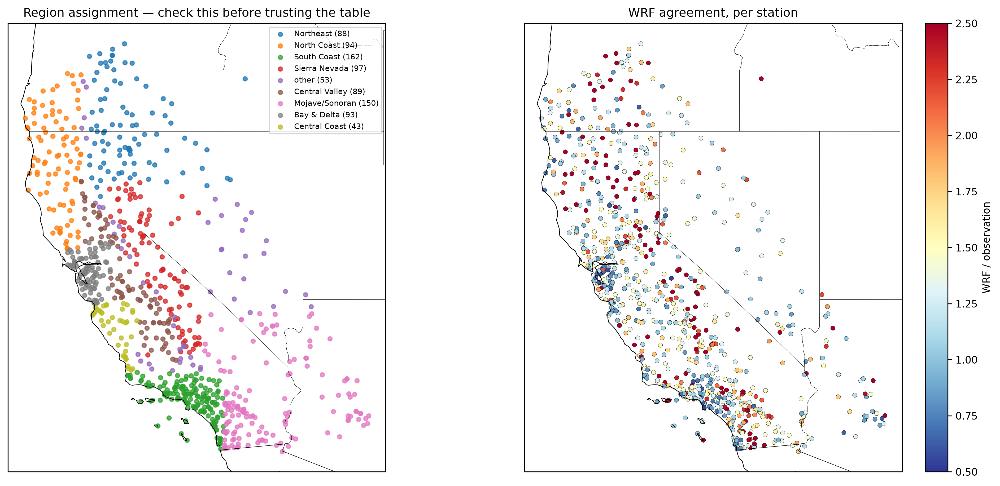

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True, subplot_kw={
                       "projection": ccrs.PlateCarree()})
for reg in pd.unique(region):
    sel = region == reg
    ax[0].scatter(slon[sel], slat[sel], s=14, alpha=0.75,
                  label=f"{reg} ({int(sel.sum())})")
ax[0].set_xlabel("longitude")
ax[0].set_ylabel("latitude")
ax[0].set_aspect(1 / np.cos(np.deg2rad(37)))
ax[0].legend(fontsize=7, loc="upper right")
ax[0].set_title("Region assignment — check this before trusting the table")

g0 = "wrf" if "wrf" in smodel else list(smodel)[0]
r0 = (smodel[g0].mean("time").values / obs_mean)
sc = ax[1].scatter(slon, slat, c=np.clip(r0, 0.5, 2.5), s=16, cmap="RdYlBu_r",
                   vmin=0.5, vmax=2.5, edgecolor="k", lw=0.2)
ax[1].set_aspect(1 / np.cos(np.deg2rad(37)))
ax[1].set_xlabel("longitude")
plt.colorbar(sc, ax=ax[1], label=f"{LABEL[g0]} / observation")
ax[1].set_title(f"{LABEL[g0]} agreement, per station")

for a in ax:
    a.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.6, zorder=3)
    a.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, zorder=3)
    a.add_feature(cfeature.STATES.with_scale("50m"), lw=0.2)


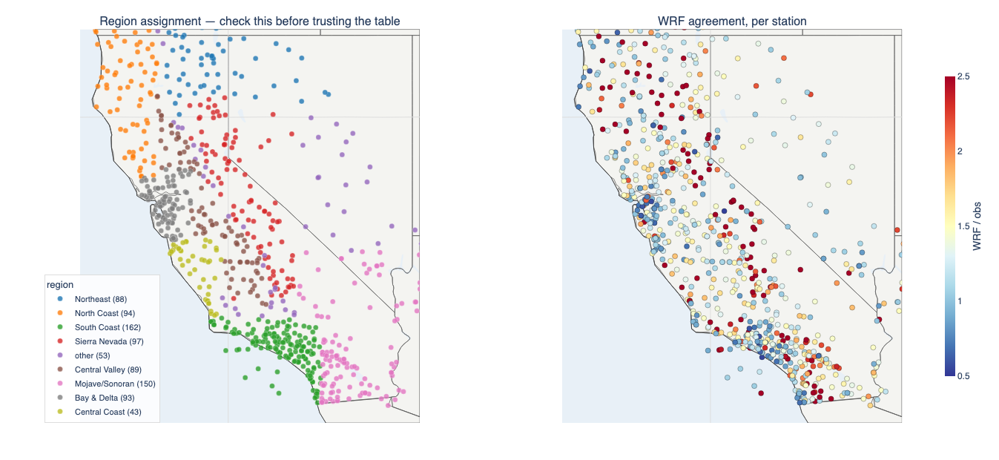

PosixPath('figures/html/region_assignment_and_agreement.html')

In [43]:
# Export: region_assignment_and_agreement
save_png(fig, "region_assignment_and_agreement")


def _plotly():
    g0 = "wrf" if "wrf" in smodel else list(smodel)[0]
    pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                       specs=[[{"type": "geo"}, {"type": "geo"}]],
                       subplot_titles=(
                           "Region assignment — check this before trusting "
                           "the table", f"{LABEL[g0]} agreement, per station"))
    for t in _region_traces():
        pf.add_trace(t, row=1, col=1)
    pf.add_trace(_ratio_trace(g0, colorbar_x=1.0), row=1, col=2)
    _geo_layout(pf, 2)
    pf.update_layout(legend=dict(x=0.0, y=0.0, xanchor="left",
                                 yanchor="bottom", title="region"))
    return style(pf, height=620)


save_html(_plotly(), "region_assignment_and_agreement")


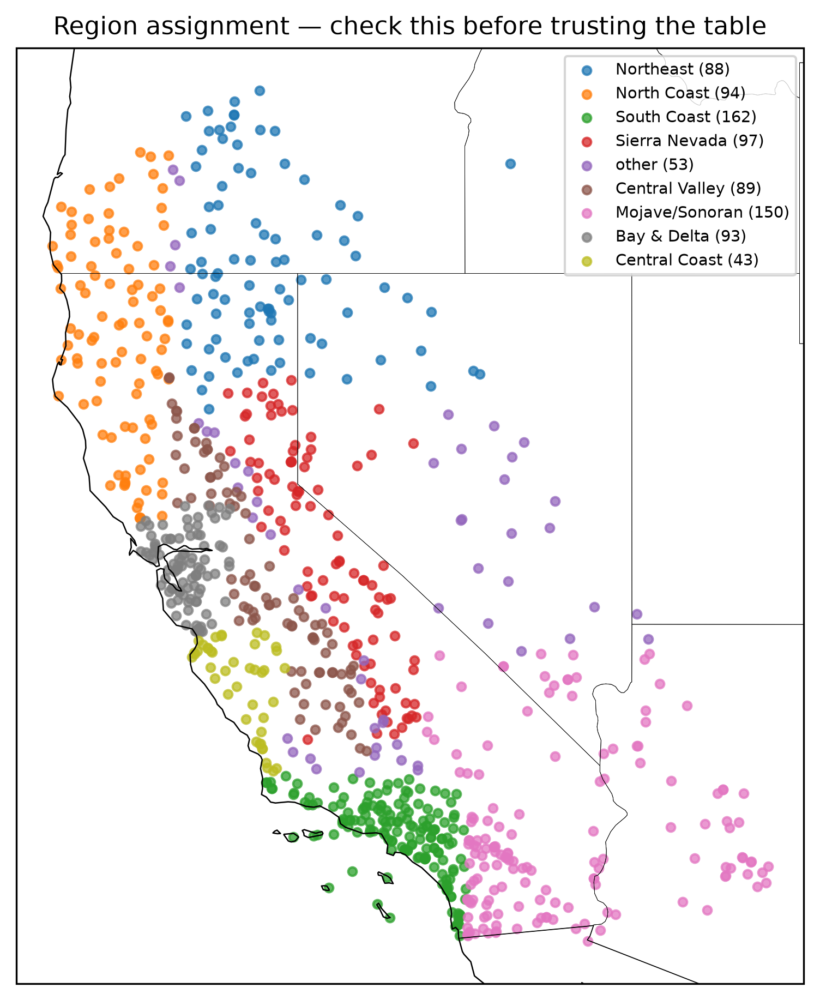

In [44]:
fig, ax = plt.subplots(figsize=(6.5, 6), constrained_layout=True, subplot_kw={
                       "projection": ccrs.PlateCarree()})
for reg in pd.unique(region):
    sel = region == reg
    ax.scatter(slon[sel], slat[sel], s=14, alpha=0.75,
               label=f"{reg} ({int(sel.sum())})")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect(1 / np.cos(np.deg2rad(37)))
ax.legend(fontsize=7, loc="upper right")
ax.set_title("Region assignment — check this before trusting the table")

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.6, zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, zorder=3)
ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.2)


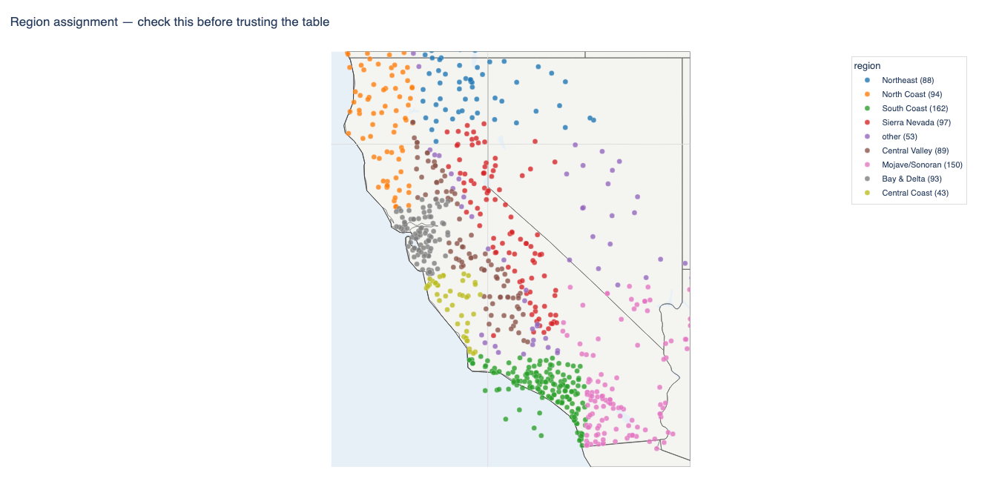

PosixPath('figures/html/region_assignment.html')

In [45]:
# Export: region_assignment
save_png(fig, "region_assignment")


def _plotly():
    pf = go.Figure(_region_traces())
    _geo_layout(pf, 1)
    pf.update_layout(legend=dict(title="region", x=0.99, y=0.99,
                                 xanchor="right", yanchor="top"))
    return style(pf, "Region assignment — check this before trusting the table",
                 height=680, width=680)


save_html(_plotly(), "region_assignment")


,n,n_air,LOCA2 all,LOCA2 air,WRF all,WRF air
region,,,,,,
Northeast,88,10,1.108,0.827,1.427,1.110
South Coast,162,60,1.155,1.052,1.202,0.952
Central Valley,89,25,1.163,0.996,1.316,1.064
Mojave/Sonoran,150,46,1.185,0.873,1.459,1.020
North Coast,94,12,1.198,1.122,1.393,1.050
Central Coast,43,8,1.214,0.983,1.338,0.917
Bay & Delta,93,25,1.219,1.046,1.155,0.811
Sierra Nevada,97,11,1.274,1.018,1.650,1.106


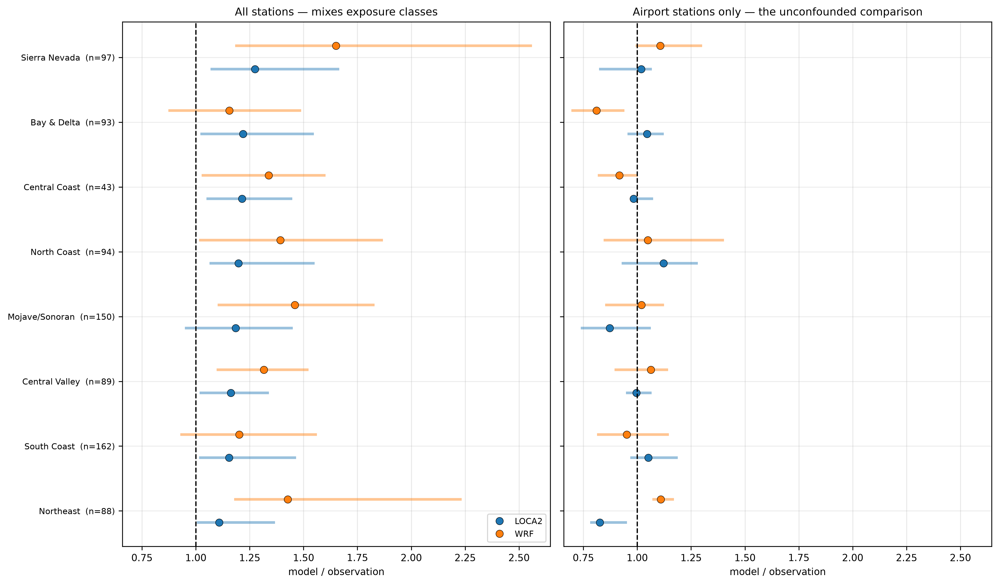

In [46]:
# Agreement by region: median, spread, and the airport-only subset.
#
# Three things on one axis, because they answer different questions and are
# easily confused:
#   dot        median ratio over ALL stations in the region -- mixes exposure
#              classes, so it partly measures which networks operate there
#   bar        interquartile range: whether the median describes the stations
#              or is the centre of a wide, cancelling spread
#   right panel  airports only -- the unconfounded comparison, where it exists
regs = [r for r, _ in CA_REGIONS if (region == r).sum() >= MIN_REGION_N]
regs = sorted(regs, key=lambda r: np.nanmedian(
    (list(smodel.values())[0].mean("time").values / obs_mean)[region == r]))

fig, ax = plt.subplots(1, 2, figsize=(13, 0.62 * len(regs) + 2.6),
                       constrained_layout=True, sharey=True)
off = np.linspace(-0.18, 0.18, max(len(smodel), 2))[:len(smodel)]

for j, (panel, only_air) in enumerate([(ax[0], False), (ax[1], True)]):
    for gi, (g, m) in enumerate(smodel.items()):
        r_all = m.mean("time").values / obs_mean
        y, med, lo, hi = [], [], [], []
        for k, reg in enumerate(regs):
            sel = region == reg
            if only_air:
                sel = sel & (expo == "airport")
            r = r_all[sel]
            r = r[np.isfinite(r)]
            # A median of four stations is not a regional statistic. Airports
            # need a higher floor because they are the scarcer class.
            if r.size < (8 if only_air else 5):
                continue
            y.append(k + off[gi])
            med.append(np.median(r))
            lo.append(np.percentile(r, 25))
            hi.append(np.percentile(r, 75))
        if not y:
            continue
        panel.hlines(y, lo, hi, color=COLOR[g], lw=2.5, alpha=0.45)
        panel.plot(med, y, "o", color=COLOR[g], ms=7, label=LABEL[g],
                   markeredgecolor="k", markeredgewidth=0.4)
    panel.axvline(1, color="k", lw=1.2, ls="--")
    panel.set_yticks(range(len(regs)))
    panel.set_yticklabels(
        [f"{r}  (n={int((region == r).sum())}"
         + (f", air={int(((region == r) & (expo == 'airport')).sum())})"
            if not only_air else ")")
         for r in regs], fontsize=8)
    panel.set_xlabel("model / observation")
    panel.grid(axis="x", alpha=0.3)
for a, t in zip(ax, ("All stations — mixes exposure classes",
                     "Airport stations only — the unconfounded comparison")):
    a.set_title(t, fontsize=10)
ax[0].legend(fontsize=8, loc="lower right")

# One shared x-range, so the two panels are visually comparable rather than
# each auto-scaled to its own spread.
lo = min(a.get_xlim()[0] for a in ax)
hi = max(a.get_xlim()[1] for a in ax)
for a in ax:
    a.set_xlim(lo, hi)

rows = []
for reg in regs:
    sel = region == reg
    air = sel & (expo == "airport")
    row = {"region": reg, "n": int(sel.sum()), "n_air": int(air.sum())}
    for g, m in smodel.items():
        r_all = m.mean("time").values / obs_mean
        a_all = np.nanmedian(r_all[sel])
        a_air = np.nanmedian(r_all[air]) if air.sum() >= 8 else np.nan
        row[f"{LABEL[g]} all"] = a_all
        row[f"{LABEL[g]} air"] = a_air
    rows.append(row)
display(pd.DataFrame(rows).set_index("region").round(3))


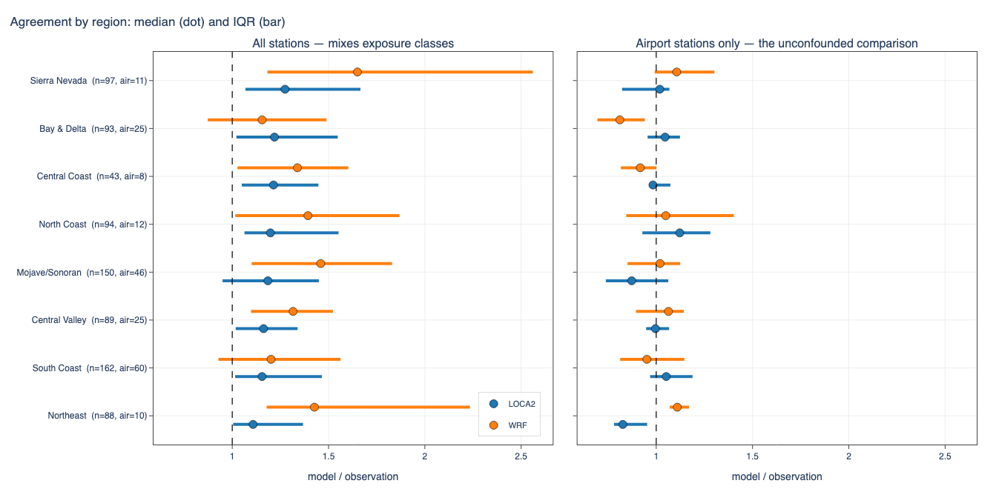

PosixPath('figures/html/agreement_by_region.html')

In [47]:
# Export: agreement_by_region
save_png(fig, "agreement_by_region")


def _plotly():
    off_ = np.linspace(-0.18, 0.18, max(len(smodel), 2))[:len(smodel)]
    pf = make_subplots(rows=1, cols=2, shared_yaxes=True,
                       horizontal_spacing=0.03, subplot_titles=(
                           "All stations — mixes exposure classes",
                           "Airport stations only — the unconfounded comparison"))
    for c, only_air in ((1, False), (2, True)):
        for gi, (g, m) in enumerate(smodel.items()):
            r_all = m.mean("time").values / obs_mean
            y, med, lo, hi, n, names = [], [], [], [], [], []
            for k, reg in enumerate(regs):
                sel = region == reg
                if only_air:
                    sel = sel & (expo == "airport")
                r_ = r_all[sel]
                r_ = r_[np.isfinite(r_)]
                if r_.size < (8 if only_air else 5):
                    continue
                y.append(k + off_[gi])
                med.append(np.median(r_))
                lo.append(np.percentile(r_, 25))
                hi.append(np.percentile(r_, 75))
                n.append(r_.size)
                names.append(reg)
            if not y:
                continue
            med, lo, hi = map(np.asarray, (med, lo, hi))
            pf.add_trace(go.Scatter(
                x=med, y=y, mode="markers", name=LABEL[g], legendgroup=g,
                showlegend=c == 1,
                marker=dict(size=11, color=PCOLOR[g],
                            line=dict(color="black", width=0.6)),
                error_x=dict(type="data", symmetric=False, array=hi - med,
                             arrayminus=med - lo, color=PCOLOR[g],
                             thickness=4, width=0),
                text=[f"<b>{LABEL[g]}</b> — {nm}<br>median {md:.3f}"
                      f"<br>IQR {a:.3f}–{b:.3f}<br>n={nn}"
                      for nm, md, a, b, nn in zip(names, med, lo, hi, n)],
                hovertemplate="%{text}<extra></extra>"),
                row=1, col=c)
        pf.add_vline(x=1, line=dict(color="black", dash="dash", width=1.2),
                     row=1, col=c)
        pf.update_xaxes(title="model / observation", row=1, col=c)
    pf.update_xaxes(matches="x", row=1, col=2)   # one shared x-range
    ticks = [f"{r}  (n={int((region == r).sum())}, "
             f"air={int(((region == r) & (expo == 'airport')).sum())})"
             for r in regs]
    pf.update_yaxes(tickvals=list(range(len(regs))), ticktext=ticks,
                    range=[-0.6, len(regs) - 0.4], row=1, col=1)
    pf.update_layout(legend=dict(x=0.47, y=0.02, xanchor="right",
                                 yanchor="bottom"))
    return style(pf, "Agreement by region: median (dot) and IQR (bar)",
                 height=int(55 * len(regs) + 220))


save_html(_plotly(), "agreement_by_region")


### Findings

**Agreement is regionally uniform at airports and regionally structured
everywhere else.**

Airport-only ratios (the unconfounded column):

| region | n_air | LOCA2 | WRF |
|---|---|---|---|
| North Coast | 12 | 1.122 | 1.050 |
| Bay & Delta | 25 | 1.046 | **0.811** |
| Central Coast | 8 | 0.983 | 0.917 |
| South Coast | 60 | 1.052 | 0.952 |
| Sierra Nevada | 11 | 1.018 | 1.106 |
| Central Valley | 25 | 0.996 | 1.064 |
| Mojave/Sonoran | 46 | **0.873** | 1.020 |
| Northeast | 10 | **0.827** | 1.110 |

**Most regions sit within ±10 % of 1.0 for both products.** The domain-wide
airport result of §1 is not an average of large opposing regional errors; it
holds region by region.

**The exceptions are informative and not shared.** LOCA2 runs low in the
Mojave (0.873) and Northeast (0.827) — the two most arid, thermally driven
regions, where WRF is fine (1.020, 1.110). WRF runs low in the Bay & Delta
(0.811), the one region whose wind climate is dominated by a sea breeze
through a single topographic feature. Each product fails in a regime the other
handles.

### 5.2 Seasonal cycle, region by region

A single domain-wide seasonal statement can hide two opposite regional ones. The
Central Valley and the Sierra do not share a wind season, so a flat pooled curve
could be two curves cancelling.

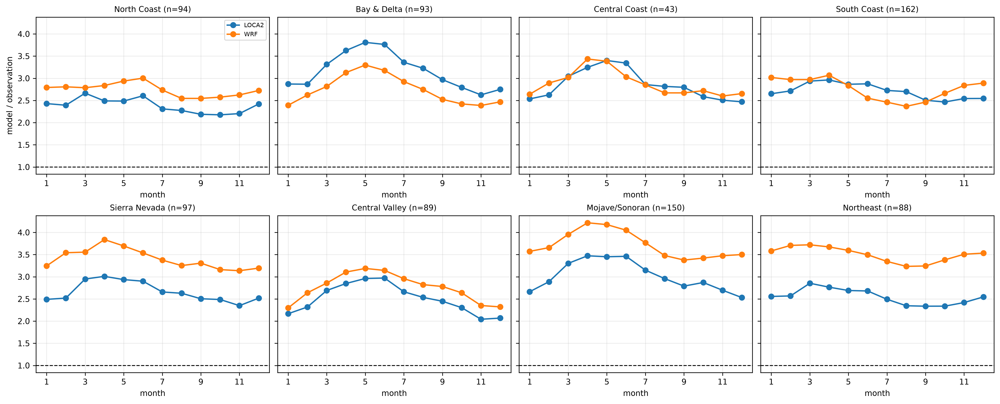

In [48]:
regs = [r for r, _ in CA_REGIONS if (region == r).sum() >= MIN_REGION_N]
ncol = min(4, max(len(regs), 1))
nrow = int(np.ceil(max(len(regs), 1) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow),
                       constrained_layout=True, squeeze=False, sharey=True)

for k, reg in enumerate(regs):
    a = ax[k // ncol][k % ncol]
    sel = region == reg
    for g, m in smodel.items():
        r = ((m.groupby("time.month").mean())
             .transpose("month", "station_id").values[:, sel])
        med = np.nanmedian(r, axis=1)
        a.plot(range(1, 13), med, "o-", color=COLOR[g], lw=1.6, label=LABEL[g])
    a.axhline(1, color="k", lw=1, ls="--")
    a.set_title(f"{reg} (n={int(sel.sum())})", fontsize=9)
    a.set_xticks(range(1, 13, 2))
    a.set_xlabel("month")
ax[0][0].set_ylabel("model / observation")
if regs:
    ax[0][0].legend(fontsize=7)
for k in range(len(regs), nrow * ncol):
    ax[k // ncol][k % ncol].set_visible(False)


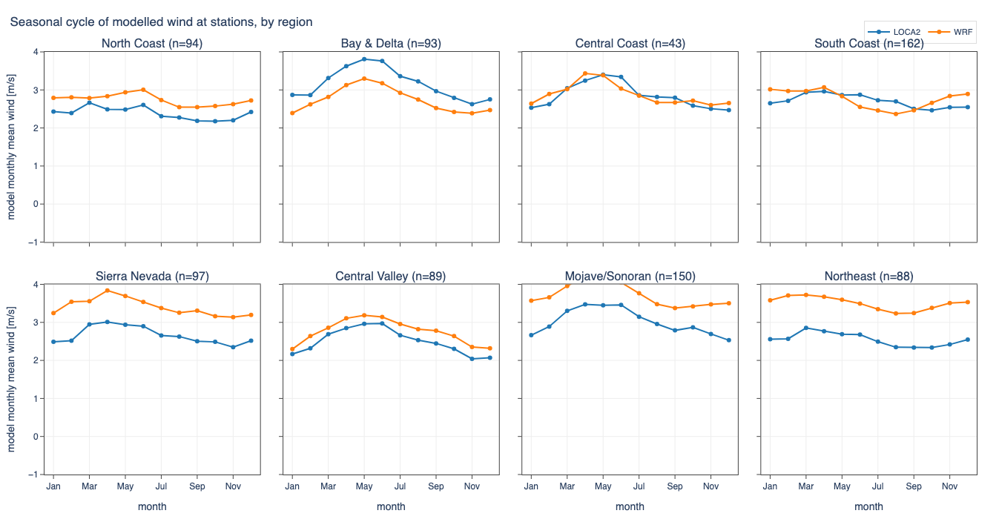

PosixPath('figures/html/abs_seasonal_by_region.html')

In [49]:
# Export: abs_seasonal_by_region
save_png(fig, "abs_seasonal_by_region")

def _facets(values_of, ytitle, title, ref=None):
    """One subplot per region; values_of(m, sel) -> 12 monthly values."""
    regs_ = [r for r, _ in CA_REGIONS if (region == r).sum() >= MIN_REGION_N]
    ncol = min(4, max(len(regs_), 1))
    nrow = int(np.ceil(max(len(regs_), 1) / ncol))
    pf = make_subplots(
        rows=nrow, cols=ncol, shared_yaxes=True, shared_xaxes=True,
        horizontal_spacing=0.025, vertical_spacing=0.1,
        subplot_titles=[f"{r} (n={int((region == r).sum())})" for r in regs_])
    for k, reg in enumerate(regs_):
        rr, cc = k // ncol + 1, k % ncol + 1
        sel = region == reg
        for g, m in smodel.items():
            pf.add_trace(go.Scatter(
                x=list(range(1, 13)), y=values_of(m, sel), mode="lines+markers",
                name=LABEL[g], legendgroup=g, showlegend=k == 0,
                line=dict(color=PCOLOR[g], width=2), marker=dict(size=6),
                customdata=MONTHS,
                hovertemplate=f"<b>{LABEL[g]}</b> — {reg}"
                              "<br>%{customdata}: %{y:.3f}<extra></extra>"),
                row=rr, col=cc)
        if ref is not None:
            pf.add_hline(y=ref, line=dict(color="black", dash="dash", width=1),
                         row=rr, col=cc)
    pf.update_xaxes(tickvals=list(range(1, 13, 2)),
                    ticktext=MONTHS[::2], range=[0.5, 12.5])
    for cc in range(1, ncol + 1):
        pf.update_xaxes(title="month", row=nrow, col=cc)
    for rr in range(1, nrow + 1):
        pf.update_yaxes(title=ytitle, row=rr, col=1)
    pf.update_layout(legend=dict(orientation="h", y=1.02, yanchor="bottom",
                                 x=1, xanchor="right"))
    return style(pf, title, height=280 * nrow + 140)


# Absolute model climatology (m/s), so no ratio-of-1 reference line here.
save_html(_facets(
    lambda m, sel: np.nanmedian(m.groupby("time.month").mean()
                                .transpose("month", "station_id")
                                .values[:, sel], axis=1),
    ytitle="model monthly mean wind [m/s]",
    title="Seasonal cycle of modelled wind at stations, by region"),
    "abs_seasonal_by_region")


n    DJF    JJA  max-min  peak month
region         product                                        
North Coast    LOCA2     94  1.209  1.236    0.101           1
               WRF       94  1.395  1.306    0.167          10
Bay & Delta    LOCA2     93  1.252  1.209    0.194           1
               WRF       93  1.134  1.153    0.091          11
Central Coast  LOCA2     43  1.234  1.186    0.116           1
               WRF       43  1.324  1.283    0.230           5
South Coast    LOCA2    162  1.162  1.152    0.115           3
               WRF      162  1.273  1.143    0.169          12
Sierra Nevada  LOCA2     97  1.361  1.258    0.198           1
               WRF       97  1.802  1.651    0.287           1
Central Valley LOCA2     89  1.144  1.157    0.139           1
               WRF       89  1.235  1.323    0.178          11
Mojave/Sonoran LOCA2    150  1.186  1.205    0.098           6
               WRF      150  1.530  1.401    0.206          12
Northeast      LOCA2     88  1.180  1.095    0.192           1
               WRF       88  1.550  1.442    0.338           1

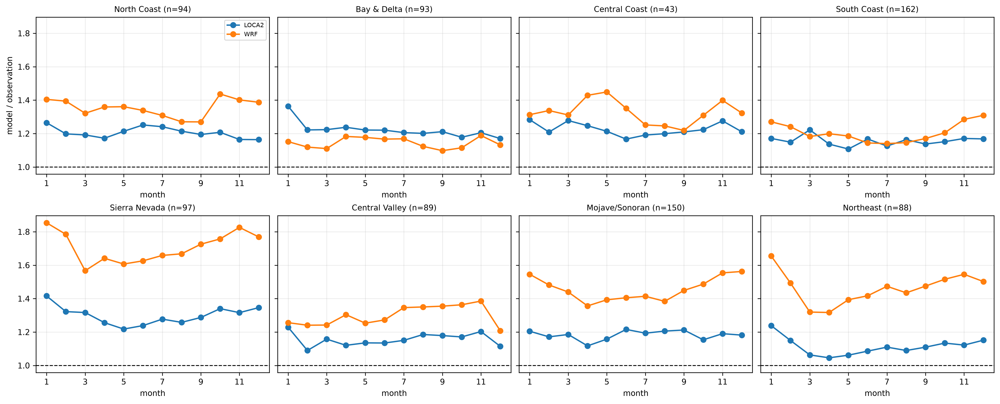

In [50]:
# The seasonal cycle of agreement, region by region.
#
# A single domain-wide seasonal statement can hide two opposite regional ones,
# which is the whole reason for splitting it.
regs = [r for r, _ in CA_REGIONS if (region == r).sum() >= MIN_REGION_N]
ncol = min(4, max(len(regs), 1))
nrow = int(np.ceil(max(len(regs), 1) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow),
                       constrained_layout=True, squeeze=False, sharey=True)
o_clim = stn["station"].groupby("time.month").mean()

summary = []
for k, reg in enumerate(regs):
    a = ax[k // ncol][k % ncol]
    sel = region == reg
    for g, m in smodel.items():
        r = ((m.groupby("time.month").mean() / o_clim)
             .transpose("month", "station_id").values[:, sel])
        med = np.nanmedian(r, axis=1)
        a.plot(range(1, 13), med, "o-", color=COLOR[g], lw=1.6, label=LABEL[g])
        summary.append({"region": reg, "product": LABEL[g],
                        "n": int(sel.sum()),
                        "DJF": np.nanmean(med[[11, 0, 1]]),
                        "JJA": np.nanmean(med[5:8]),
                        "max-min": float(med.max() - med.min()),
                        "peak month": int(np.argmax(med)) + 1})
    a.axhline(1, color="k", lw=1, ls="--")
    a.set_title(f"{reg} (n={int(sel.sum())})", fontsize=9)
    a.set_xticks(range(1, 13, 2))
    a.set_xlabel("month")
ax[0][0].set_ylabel("model / observation")
if regs:
    ax[0][0].legend(fontsize=7)
for k in range(len(regs), nrow * ncol):
    ax[k // ncol][k % ncol].set_visible(False)

if summary:
    display(pd.DataFrame(summary).set_index(["region", "product"]).round(3))


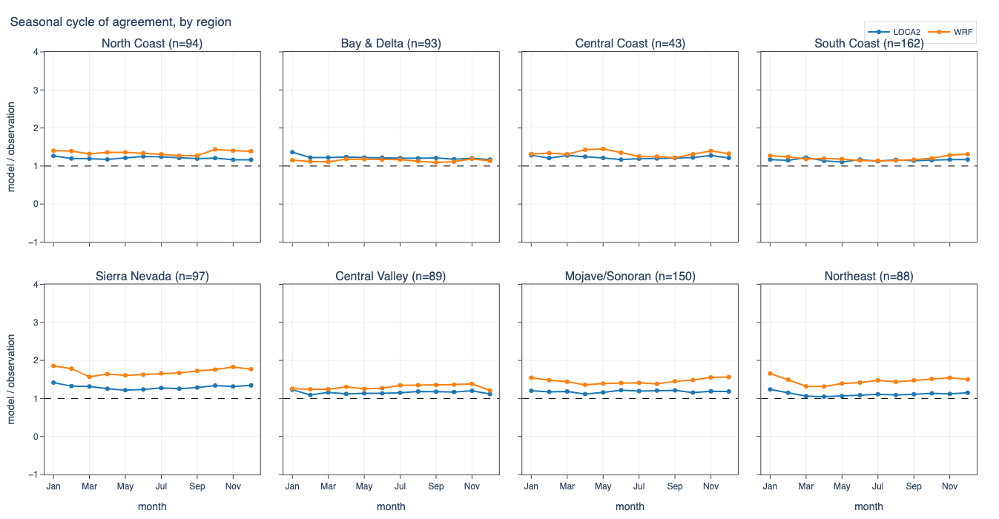

PosixPath('figures/html/seasonal_by_region.html')

In [51]:
# Export: seasonal_by_region
save_png(fig, "seasonal_by_region")

_oc = stn["station"].groupby("time.month").mean()
save_html(_facets(
    lambda m, sel: np.nanmedian((m.groupby("time.month").mean() / _oc)
                                .transpose("month", "station_id")
                                .values[:, sel], axis=1),
    ytitle="model / observation",
    title="Seasonal cycle of agreement, by region", ref=1),
    "seasonal_by_region")


### Findings

- **The seasonal cycle of agreement is resolved equally in difrerent regions.**

- **Both products agree slightly better in summer than in winter.** 

- **LOCA2 peaks in January almost everywhere** (6 of 8 regions) while WRF's peak
month scatters across October, November, December, January and May. 

---
## 6. Extremes, against observations

Daily maxima, model against station, at the same points.

**LOCA2 cannot appear.** It publishes only `wspeed`, a mean, and no
maximum-wind variable at any cadence.

**One asymmetry to keep in view.** WRF's `wspd10max` is a maximum over model
timesteps; the observed side is a maximum over hourly reports. A model timestep
maximum is higher than an hourly-sampled one for the same wind field, so the
ratios below are an **upper bound** on the true discrepancy.

In [52]:
# Daily maxima, observed against modelled, from station_daily.
#
# LOCA2 cannot appear: it publishes no maximum-wind variable at any cadence.
# That is a data-availability verdict on the extreme-wind use case, independent
# of any bias.
obs_max = sd["obs_max"]
at_max = merge_wrf({k.replace("max_", ""): sd[k] for k in sd.data_vars
                    if k.startswith("max_")})

if not at_max:
    print("No modelled daily maxima in station_daily. Fetch and rebuild:\n"
          "  python src/fetch_local.py wspd10max --cadence day "
          "--products wrf-gcm wrf-era5\n"
          "  python src/build_metrics.py --stages station_daily --overwrite")
else:
    rows = []
    for p, m in at_max.items():
        o, mm = xr.align(obs_max, m, join="inner")
        groups = ["all"] + [c for c in ("airport", "vegetated")
                            if (expo_d == c).sum() >= 10]
        for cls in groups:
            sel = (np.ones(o.sizes["station_id"], bool) if cls == "all"
                   else np.isin([str(s) for s in o.station_id.values],
                                [sids_d[i] for i in
                                 np.where(expo_d == cls)[0]]))
            ov = o.isel(station_id=np.where(sel)[0]).values.ravel()
            mv = mm.isel(station_id=np.where(sel)[0]).values.ravel()
            ok = np.isfinite(ov) & np.isfinite(mv)
            ov, mv = ov[ok], mv[ok]
            rows.append({
                "product": LABEL[p], "group": cls, "n_days": int(ok.sum()),
                "mean ratio": mv.mean() / ov.mean(),
                "q90 ratio": np.quantile(mv, .90) / np.quantile(ov, .90),
                "q99 ratio": np.quantile(mv, .99) / np.quantile(ov, .99),
                "obs P(>10 m/s)": (ov > 10).mean(),
                "mod P(>10 m/s)": (mv > 10).mean()})
    display(pd.DataFrame(rows).set_index(["product", "group"]).round(3))
    print("\nwspd10max is a maximum over MODEL TIMESTEPS; the observed side is\n"
          "a maximum over HOURLY REPORTS. The model is higher by construction,\n"
          "so these ratios are an upper bound on the true discrepancy.")

n_days  mean ratio  q90 ratio  q99 ratio  obs P(>10 m/s)  \
product group                                                                
WRF     all      4225377       1.124      0.974      0.867           0.058   
        airport  1044961       0.835      0.786      0.782           0.105   

                 mod P(>10 m/s)  
product group                    
WRF     all               0.044  
        airport           0.027


wspd10max is a maximum over MODEL TIMESTEPS; the observed side is
a maximum over HOURLY REPORTS. The model is higher by construction,
so these ratios are an upper bound on the true discrepancy.


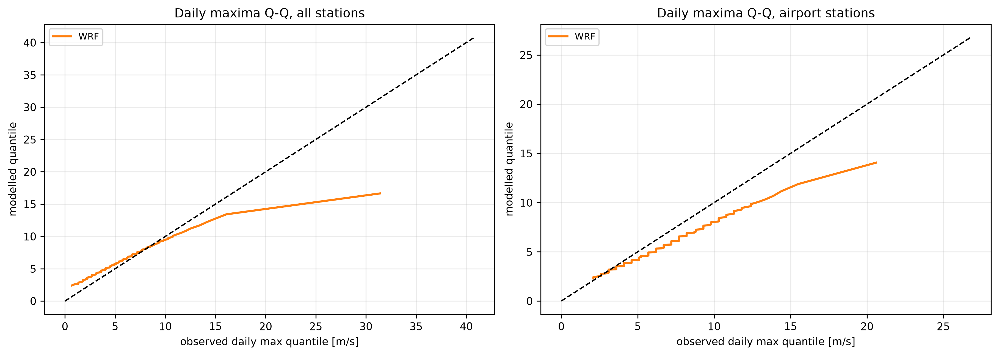

In [53]:
if at_max:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    q = np.linspace(0.01, 0.999, 200)
    air = expo_d == "airport"
    for j, (sel, title) in enumerate([(np.ones(len(air), bool), "all stations"),
                                      (air, "airport stations")]):
        if sel.sum() < 5:
            continue
        for p, m in at_max.items():
            o, mm = xr.align(obs_max, m, join="inner")
            ov = o.isel(station_id=np.where(sel)[0]).values.ravel()
            mv = mm.isel(station_id=np.where(sel)[0]).values.ravel()
            ok = np.isfinite(ov) & np.isfinite(mv)
            oq = np.quantile(ov[ok], q)
            ax[j].plot(oq, np.quantile(mv[ok], q), color=COLOR[p], lw=1.8,
                       label=LABEL[p])
        lim = [0, oq.max() * 1.3]
        ax[j].plot(lim, lim, "k--", lw=1.2)
        ax[j].set_xlabel("observed daily max quantile [m/s]")
        ax[j].set_ylabel("modelled quantile")
        ax[j].legend(fontsize=8)
        ax[j].set_title(f"Daily maxima Q-Q, {title}")


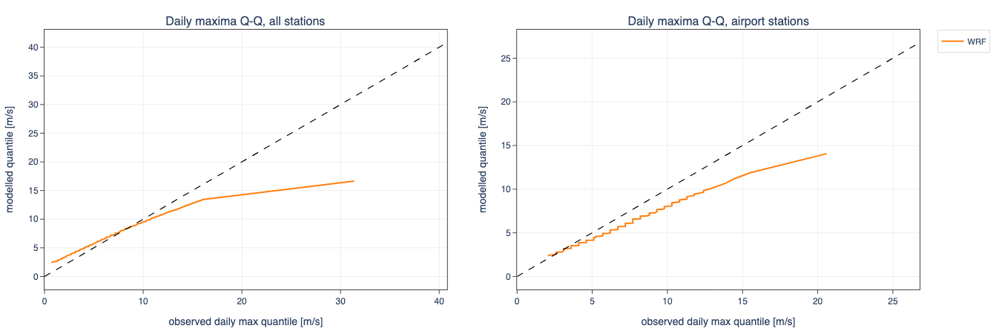

In [54]:
# Export: extremes_stations
if at_max:
    save_png(fig, "extremes_stations")

    def _plotly():
        q_ = np.linspace(0.01, 0.999, 200)
        air_ = expo_d == "airport"
        pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                           subplot_titles=("Daily maxima Q-Q, all stations",
                                           "Daily maxima Q-Q, airport stations"))
        for c, sel in ((1, np.ones(len(air_), bool)), (2, air_)):
            if sel.sum() < 5:
                continue
            top = 0
            for p, m in at_max.items():
                o_, mm_ = xr.align(obs_max, m, join="inner")
                ov = o_.isel(station_id=np.where(sel)[0]).values.ravel()
                mv = mm_.isel(station_id=np.where(sel)[0]).values.ravel()
                ok = np.isfinite(ov) & np.isfinite(mv)
                oq_ = np.quantile(ov[ok], q_)
                top = max(top, oq_.max())
                pf.add_trace(go.Scatter(
                    x=oq_, y=np.quantile(mv[ok], q_), mode="lines",
                    name=LABEL[p], legendgroup=p, showlegend=c == 1,
                    line=dict(color=PCOLOR[p], width=2), customdata=q_ * 100,
                    hovertemplate=f"<b>{LABEL[p]}</b><br>p%{{customdata:.1f}}: "
                                  "obs %{x:.2f} → model %{y:.2f} m/s"
                                  "<extra></extra>"),
                    row=1, col=c)
            ref_line(pf, 0, top * 1.3, row=1, col=c)
            pf.update_xaxes(title="observed daily max quantile [m/s]",
                            row=1, col=c)
            pf.update_yaxes(title="modelled quantile [m/s]", row=1, col=c)
        return style(pf, height=450)

    save_html(_plotly(), "extremes_stations")


### Findings

**The models do not produce enough high-wind days, and the shortfall gets worse the further into the tail you look.**

| group | mean ratio | q90 ratio | q99 ratio |
|---|---|---|---|
| all stations | 1.124 | 0.974 | **0.867** |
| airports | 0.835 | 0.786 | **0.782** |

**The ratios fall monotonically with quantile.** A scale-factor error would keep
them flat. Falling ratios mean the modelled distribution is too narrow at the
top, agreeing with the findings at §2.1's Weibull shape, arrived at independently from
daily maxima.

**The exceedance columns make the operational cost concrete.**

| group | observed P(>10 m/s) | modelled P(>10 m/s) |
|---|---|---|
| all stations | 5.8 % | 4.4 % |
| **airports** | **10.5 %** | **2.7 %** |

At airports the model produces high-wind days at **one quarter** the observed
rate.

This is an important result in the notebook for the **fire-weather and design-load use cases**, 
and it is invisible in every mean-based metric.

---
## 7. Diurnal cycle, against observations

For now, we'll skip the diurnal cycle analysis since we don't know 
how valid would be to compare hourly data to observed weather stations.

---
## 8. ERA5: where and when coarse and fine fields diverge

ERA5 enters last, and in a specific role. Sections 1–8 have already settled what
matters: the products are close to right at well-sited stations, consistent with
an independent km-scale model, and limited mainly by cadence and variable
coverage.

ERA5 is used here for the one thing stations and CONUS404 cannot provide —
**complete, uniform spatial and temporal coverage**. Stations are points, absent
over the ocean and sparse above 2,000 m; CONUS404 covers a different domain. So
the question in this section is not *"are the products right?"* but:

> **Where, and under what conditions, does a 31 km field differ from a 3 km one,
> and does the pattern match what resolution predicts?**

Read every ratio below as a **distance from a coarse reanalysis**, not an error.
The grid, terrain and land/ocean masks were loaded in §0.

In [55]:
rows = []
for g in REPORTED:
    cc = CTX[g]
    keep = cc["keep"].astype(bool)
    m = xr.Dataset({"ratio": ratio_of(cc).where(keep),
                    "var_ratio": var_ratio_of(cc).where(keep)}).compute()
    lfp, _ = xr.align(grids.land_fraction, m.ratio, join="right")
    df = region_summary(m, region_masks(lfp), extra=("var_ratio",), quiet=True)
    df["product"] = LABEL[g]
    rows.append(df.reset_index())
tab = pd.concat(rows).pivot(index="product", columns="region",
                            values=["ratio", "var_ratio"])
display(tab.round(3))

ratio                      var_ratio                     
region   coastal   land  ocean pooled   coastal   land  ocean pooled
product                                                             
CONUS404   1.180  1.522  0.996  1.124     0.967  1.253  0.985  1.026
LOCA2      1.163  1.289    NaN  1.285     1.239  1.281    NaN  1.280
WRF        1.167  1.617  0.995  1.458     0.799  0.946  0.793  0.855

Text(0.5, 1.0, 'Dose-response in land fraction')

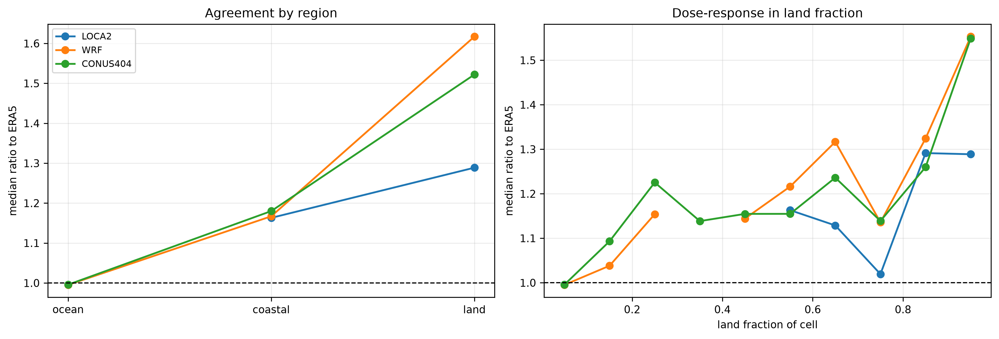

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
order = ["ocean", "coastal", "land"]
x = np.arange(len(order))
for g in REPORTED:
    cc = CTX[g]
    keep = cc["keep"].astype(bool)
    r = ratio_of(cc).where(keep).compute()
    lfp, _ = xr.align(grids.land_fraction, r, join="right")
    rm = region_masks(lfp)
    ax[0].plot(x, [float(np.nanmedian(r.where(rm[k]).values)) for k in order],
               "o-", color=COLOR[g], label=LABEL[g], lw=1.6)
    # Ratio against land fraction directly: a step at the coastline would mean
    # a land-surface difference; a gradient means the discrepancy scales with
    # how much terrain a cell contains, which is what resolution predicts.
    lfv, rv = lfp.values.ravel(), r.values.ravel()
    ok = np.isfinite(lfv) & np.isfinite(rv)
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(lfv[ok], bins) - 1
    ax[1].plot(bins[:-1] + 0.05,
               [np.nanmedian(rv[ok][idx == b]) if (idx == b).sum() > 5 else np.nan
                for b in range(10)], "o-", color=COLOR[g], lw=1.6)
for a in ax:
    a.axhline(1, color="k", lw=1, ls="--")
    a.set_ylabel("median ratio to ERA5")
ax[0].set_xticks(x)
ax[0].set_xticklabels(order)
ax[0].legend(fontsize=8)
ax[0].set_title("Agreement by region")
ax[1].set_xlabel("land fraction of cell")
ax[1].set_title("Dose-response in land fraction")


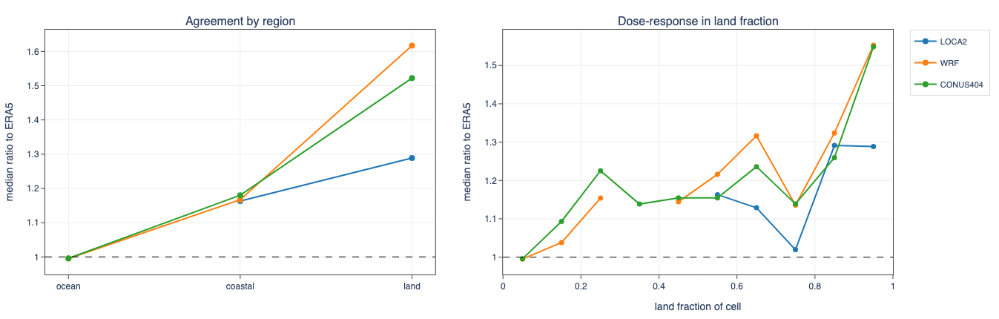

PosixPath('figures/html/ratio_by_region.html')

In [57]:
# Export: ratio_by_region
save_png(fig, "ratio_by_region")


def _plotly():
    order_ = ["ocean", "coastal", "land"]
    bins_ = np.linspace(0, 1, 11)
    pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                       subplot_titles=("Agreement by region",
                                       "Dose-response in land fraction"))
    for g in REPORTED:
        cc = CTX[g]
        r_ = ratio_of(cc).where(cc["keep"].astype(bool)).compute()
        lfp, _ = xr.align(grids.land_fraction, r_, join="right")
        rm = region_masks(lfp)
        pf.add_trace(go.Scatter(
            x=order_, y=[float(np.nanmedian(r_.where(rm[k]).values))
                         for k in order_],
            mode="lines+markers", name=LABEL[g], legendgroup=g,
            line=dict(color=PCOLOR[g], width=2), marker=dict(size=8),
            hovertemplate=f"<b>{LABEL[g]}</b> %{{x}}: %{{y:.3f}}"
                          "<extra></extra>"), row=1, col=1)
        lfv, rv = lfp.values.ravel(), r_.values.ravel()
        ok = np.isfinite(lfv) & np.isfinite(rv)
        idx = np.digitize(lfv[ok], bins_) - 1
        n = np.array([(idx == b).sum() for b in range(10)])
        med = [np.nanmedian(rv[ok][idx == b]) if n[b] > 5 else np.nan
               for b in range(10)]
        pf.add_trace(go.Scatter(
            x=bins_[:-1] + 0.05, y=med, mode="lines+markers", name=LABEL[g],
            legendgroup=g, showlegend=False,
            line=dict(color=PCOLOR[g], width=2), marker=dict(size=7),
            customdata=np.column_stack([bins_[:-1], bins_[1:], n]),
            hovertemplate=f"<b>{LABEL[g]}</b><br>land fraction "
                          "%{customdata[0]:.1f}–%{customdata[1]:.1f}"
                          "<br>median ratio %{y:.3f}<br>n=%{customdata[2]}"
                          "<extra></extra>"), row=1, col=2)
    for c in (1, 2):
        pf.add_hline(y=1, line=dict(color="black", dash="dash", width=1),
                     row=1, col=c)
        pf.update_yaxes(title="median ratio to ERA5", row=1, col=c)
    pf.update_xaxes(title="land fraction of cell", range=[0, 1], row=1, col=2)
    return style(pf, height=430)


save_html(_plotly(), "ratio_by_region")


### Findings — the mechanism test

**Over open water the km-scale models and ERA5 agree to within half a percent.
Over land they diverge by 52–62 %.**

| product | ocean | coastal | land | pooled |
|---|---|---|---|---|
| WRF | **0.995** | 1.167 | **1.617** | 1.458 |
| CONUS404 | **0.996** | 1.180 | **1.522** | 1.124 |
| LOCA2 | — | 1.163 | 1.289 | 1.285 |

**The ocean column is a positive control and it is decisive.** WRF 0.995 and
CONUS404 0.996 — two independently configured 3–4 km models agreeing with a
31 km reanalysis to within 0.5 % where there is no sub-grid terrain to resolve.

**`var_ratio` splits the products.** Over land WRF gives 0.946 and CONUS404
1.253, while LOCA2 gives 1.281. WRF's interannual variability is slightly
*below* ERA5's despite a mean 62 % above it. Read alongside §2.1's
Weibull `k` of 2.92, the same picture: WRF is too strong on average and too
narrow in spread.

In [58]:
if "conus404" in CTX:
    rows = []
    for g in REPORTED:
        cc = CTX[g]
        r = ratio_of(cc).where(cc["keep"].astype(bool)).compute()
        lfp, _ = xr.align(grids.land_fraction, r, join="right")
        rm = region_masks(lfp)
        rows.append({"product": LABEL[g],
                     **{k: float(np.nanmedian(r.where(rm[k]).values))
                        for k in ("ocean", "coastal", "land")},
                     "pooled": float(np.nanmedian(r.values))})
    display(pd.DataFrame(rows).set_index("product").round(3))
else:
    print("CONUS404 absent -- run derive_conus404.py then build_metrics.py")

,ocean,coastal,land,pooled
product,,,,
LOCA2,NaN,1.163,1.289,1.285
WRF,0.995,1.167,1.617,1.458
CONUS404,0.996,1.180,1.522,1.124


### 8.1 Seasonal structure

Does the divergence have a seasonal cycle? A flat line means one scale factor
describes the whole year and the difference is structural. A winter or summer
maximum would point at a seasonally varying mechanism, or how the
storm track is represented.

Text(0.5, 1.0, 'Seasonal cycle of wind speed, land cells only')

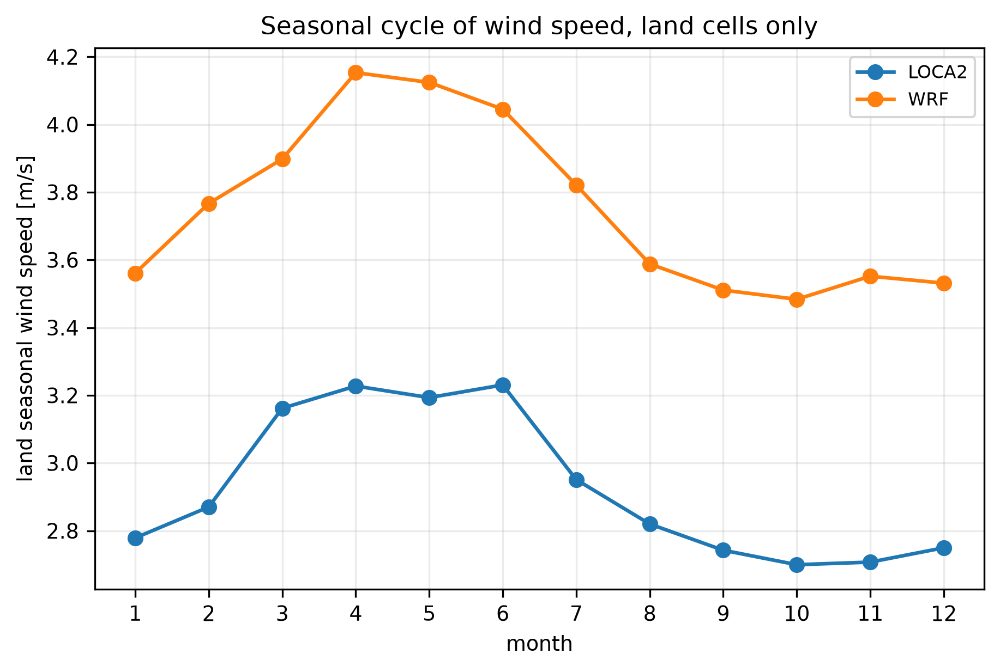

In [59]:
# Seasonal cycle and trends on the grid, per PRODUCT.
#
# seasonal_* and trends_* are stored per store, so the WRF drivers are averaged
# here the same way they are everywhere else.
def by_product(prefix, var, reduce_month=True):
    out = {}
    for g in GROUPS:
        stores = WRF_DRIVERS if g == "wrf" else [g]
        parts = [read(f"{prefix}_{s}")[var] for s in stores
                 if have(f"{prefix}_{s}")]
        if not parts:
            continue
        parts = xr.align(*parts, join="inner") if len(parts) > 1 else parts
        out[g] = (parts[0] if len(parts) == 1
                  else xr.concat(parts, dim="driver").mean("driver"))
    return out


fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for g, s in by_product("seasonal", "source_clim").items():
    lfp, _ = xr.align(grids.land_fraction, s.isel(month=0), join="right")
    land = region_masks(lfp)["land"]
    v = [float(np.nanmedian(s.isel(month=i).where(land).values))
         for i in range(12)]
    ax.plot(range(1, 13), v, "o-", color=COLOR[g], label=LABEL[g], lw=1.6)
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("land seasonal wind speed [m/s]")
ax.legend(fontsize=8)
ax.set_title("Seasonal cycle of wind speed, land cells only")


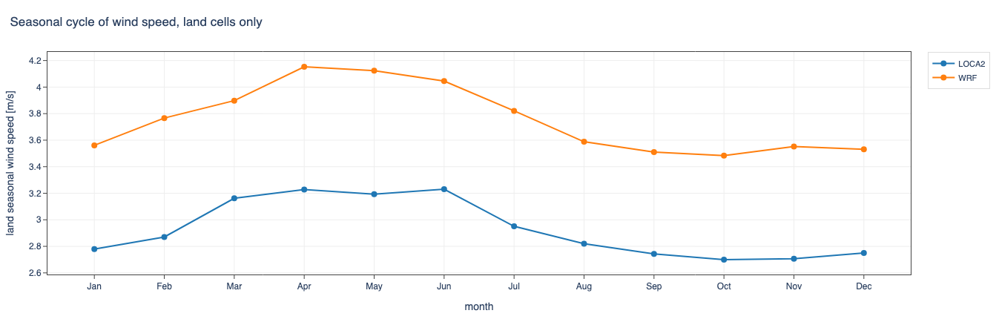

PosixPath('figures/html/abs_seasonal_trends.html')

In [60]:
# Export: abs_seasonal_trends
save_png(fig, "abs_seasonal_trends")


def _plotly():
    pf = go.Figure()
    for g, s in by_product("seasonal", "source_clim").items():
        lfp, _ = xr.align(grids.land_fraction, s.isel(month=0), join="right")
        land = region_masks(lfp)["land"]
        v = [float(np.nanmedian(s.isel(month=i).where(land).values))
             for i in range(12)]
        pf.add_trace(go.Scatter(
            x=MONTHS, y=v, mode="lines+markers", name=LABEL[g],
            line=dict(color=PCOLOR[g], width=2), marker=dict(size=8),
            hovertemplate=f"{LABEL[g]}: %{{y:.2f}} m/s<extra></extra>"))
    pf.update_xaxes(title="month")
    pf.update_yaxes(title="land seasonal wind speed [m/s]")
    return style(pf, "Seasonal cycle of wind speed, land cells only",
                 height=430, width=720, hovermode="x unified")


save_html(_plotly(), "abs_seasonal_trends")


Text(0.5, 1.0, 'Decadal trends, land cells')

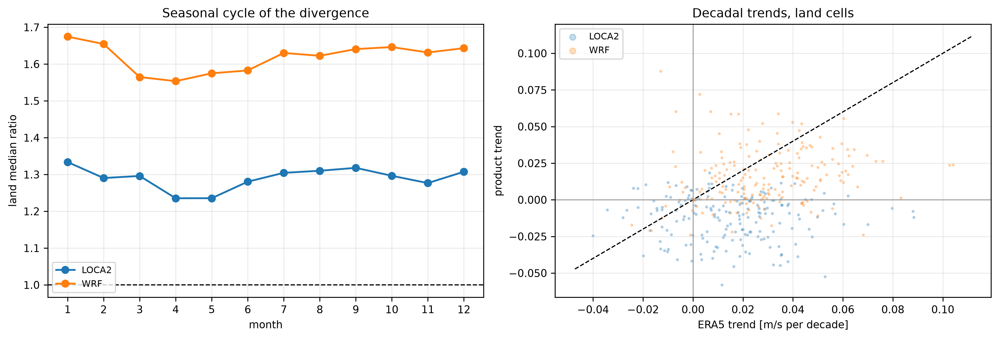

In [61]:
# Seasonal cycle and trends on the grid, per PRODUCT.
#
# seasonal_* and trends_* are stored per store, so the WRF drivers are averaged
# here the same way they are everywhere else.
def by_product(prefix, var, reduce_month=True):
    out = {}
    for g in GROUPS:
        stores = WRF_DRIVERS if g == "wrf" else [g]
        parts = [read(f"{prefix}_{s}")[var] for s in stores
                 if have(f"{prefix}_{s}")]
        if not parts:
            continue
        parts = xr.align(*parts, join="inner") if len(parts) > 1 else parts
        out[g] = (parts[0] if len(parts) == 1
                  else xr.concat(parts, dim="driver").mean("driver"))
    return out


fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for g, s in by_product("seasonal", "month_ratio").items():
    lfp, _ = xr.align(grids.land_fraction, s.isel(month=0), join="right")
    land = region_masks(lfp)["land"]
    v = [float(np.nanmedian(s.isel(month=i).where(land).values))
         for i in range(12)]
    ax[0].plot(range(1, 13), v, "o-", color=COLOR[g], label=LABEL[g], lw=1.6)
ax[0].axhline(1, color="k", lw=1, ls="--")
ax[0].set_xticks(range(1, 13))
ax[0].set_xlabel("month")
ax[0].set_ylabel("land median ratio")
ax[0].legend(fontsize=8)
ax[0].set_title("Seasonal cycle of the divergence")

src_t = by_product("trends", "source_trend")
ref_t = by_product("trends", "era5_trend")
for g in src_t:
    lfp, _ = xr.align(grids.land_fraction, src_t[g], join="right")
    land = region_masks(lfp)["land"]
    sv = src_t[g].where(land).values.ravel()
    rv = ref_t[g].where(land).values.ravel()
    ok = np.isfinite(sv) & np.isfinite(rv)
    ax[1].scatter(rv[ok][::7], sv[ok][::7], s=3, alpha=0.25,
                  color=COLOR[g], label=LABEL[g])
lim = np.array(ax[1].get_xlim())
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].axhline(0, color="0.6", lw=0.8)
ax[1].axvline(0, color="0.6", lw=0.8)
ax[1].set_xlabel("ERA5 trend [m/s per decade]")
ax[1].set_ylabel("product trend")
ax[1].legend(fontsize=8, markerscale=3)
ax[1].set_title("Decadal trends, land cells")


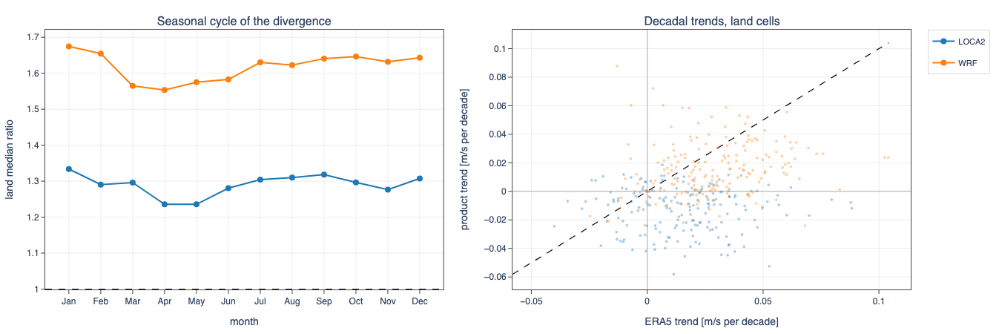

PosixPath('figures/html/seasonal_trends.html')

In [62]:
# Export: seasonal_trends
save_png(fig, "seasonal_trends")


def _plotly():
    pf = make_subplots(rows=1, cols=2, horizontal_spacing=0.08,
                       subplot_titles=("Seasonal cycle of the divergence",
                                       "Decadal trends, land cells"))
    for g, s in by_product("seasonal", "month_ratio").items():
        lfp, _ = xr.align(grids.land_fraction, s.isel(month=0), join="right")
        land = region_masks(lfp)["land"]
        v = [float(np.nanmedian(s.isel(month=i).where(land).values))
             for i in range(12)]
        pf.add_trace(go.Scatter(
            x=MONTHS, y=v, mode="lines+markers", name=LABEL[g], legendgroup=g,
            line=dict(color=PCOLOR[g], width=2), marker=dict(size=8),
            hovertemplate=f"<b>{LABEL[g]}</b> %{{x}}: %{{y:.3f}}"
                          "<extra></extra>"), row=1, col=1)
    pf.add_hline(y=1, line=dict(color="black", dash="dash", width=1),
                 row=1, col=1)

    src_t_ = by_product("trends", "source_trend")
    ref_t_ = by_product("trends", "era5_trend")
    lo, hi = np.inf, -np.inf
    for g in src_t_:
        lfp, _ = xr.align(grids.land_fraction, src_t_[g], join="right")
        land = region_masks(lfp)["land"]
        sv = src_t_[g].where(land).values.ravel()
        rv = ref_t_[g].where(land).values.ravel()
        ok = np.isfinite(sv) & np.isfinite(rv)
        xs, ys = rv[ok][::7], sv[ok][::7]
        lo, hi = min(lo, xs.min(), ys.min()), max(hi, xs.max(), ys.max())
        # WebGL scatter: thousands of cells stay responsive.
        pf.add_trace(go.Scattergl(
            x=xs, y=ys, mode="markers", name=LABEL[g], legendgroup=g,
            showlegend=False, marker=dict(size=4, opacity=0.35,
                                          color=PCOLOR[g]),
            hovertemplate=f"<b>{LABEL[g]}</b><br>ERA5 %{{x:.3f}}"
                          "<br>product %{y:.3f}<extra></extra>"),
            row=1, col=2)
    if np.isfinite(lo):
        ref_line(pf, lo, hi, row=1, col=2)
    pf.add_hline(y=0, line=dict(color="#999", width=0.8), row=1, col=2)
    pf.add_vline(x=0, line=dict(color="#999", width=0.8), row=1, col=2)
    pf.update_xaxes(title="month", row=1, col=1)
    pf.update_yaxes(title="land median ratio", row=1, col=1)
    pf.update_xaxes(title="ERA5 trend [m/s per decade]", row=1, col=2)
    pf.update_yaxes(title="product trend [m/s per decade]", row=1, col=2)
    return style(pf, height=450)


save_html(_plotly(), "seasonal_trends")


### Findings

**Gridded seasonality mirrors the station result: nearly flat, with a mildwinter excess.**

Both products agree with ERA5 slightly better in summer than in winter, matching
§3's station finding from an independent direction. 

**The trend panel is a consistency check rather than a result.** These are mostly
free-running products, so their per-cell trends need not match ERA5's. What
matters is that the cloud is centred on the 1:1 line with comparable spread,
which would indicate no systematic drift in the downscaling relationship over
the 35-year record.

---
## 9. Use-case suitability

Fitness for purpose, not a general grade. Each verdict rests on what this
notebook measured, and names what would change it.

| use case | LOCA2 | WRF |
|---|---|---|
| **Wind energy resource** | TBD | TBD|
| **Wildfire weather** | TBD | TBD |
| **Extreme wind** | TBD | TBD |
| **What other specific use cases I could add?** | TBD  | TBD  |

---
## 10. Caveats

### On the observational reference

1. **Only airports are unobstructed.** Every other class confounds model error
   with shelter (§1), and §3 shows the confound is not reducible to topography.
    Statements about model quality rest on 207 stations, not 869.
2. **Footprint.** A station is a point; a LOCA2 cell averages 9 km² and an ERA5
   cell ~950 km². Part of §1's ±10 %-only-a-third result is this and cannot be
   removed.
3. **A calm floor.** 13.2 % of hourly observations are exactly zero (§2) — the
   ASOS sub-3-kt convention. No model reproduces it, so observed means are
   biased low and every ratio here is slightly generous to the model.
4. **Reporting quantisation** onto an specific resolution. Harmless for means, relevant
   to §2.1's Weibull fits and §7's quantile ratios.
5. **338 of 1,207 stations were screened out** (§2), 292 of them for records
   under 60 months. The retained 869 are not a random sample of the archive.
6. **Coverage gaps.** No ocean stations, and few unobstructed high-terrain
   stations: the Sierra has 11 airports against 73 RAWS. The products are least
   verifiable exactly where §9 shows they diverge most from ERA5.
7. **Time coverage.** we need to re-run the station analysis and select stations where
   full years coverage exist for a more robust distribution.

### On the gridded comparison

8. **Calendars differ.** LOCA2 and WRF-GCM daily use a 365-day model calendar;
   WRF-ERA5 does not. `align(join="inner")` drops the 9 leap days.
9. **ERA5 is not bias-adjusted** and is itself a model product.
10. **CONUS404 publishes no wind speed.** Formed hourly from `U10`/`V10` and averaging to daily/monthly.

### On what is not measured

11. **No uncertainty.** Every result is a median with no bootstrap, no
    confidence interval, no effective sample size for autocorrelated series.
    It would be good for future work to run bootstrap analysis for a more robuts
    result.
12. **The AE products have no hourly data**, (WRF does, not currently in `ck.ClimateData`)
    so we don't have diurnal analysis here. Also, we don't know yet how
    correct would be to compare model agains hourly weaether station data.
13. **Historical only.** No check that skill is stationary under warming.

---
## 11. Summary

- **Both products are unbiased at well-sited stations.** 

- Median `model / observation` of **0.996 (LOCA2)** and **0.995 (WRF)** across 207 flat,
  open airport stations — two completely different downscaling methods landing
  within half a percent of observations and of each other. It holds region by
  region (§6.1) and through the seasonal cycle (§6).

- **The large ratios against ERA5 are a resolution difference, not an error.**

- **Two independently built km-scale models agree with each other.** 
  On CONUS404's own 4 km grid WRF sits at **1.020**; on common land cells the two differ by
  under 4 %. Whatever the AE WRF runs do, it is not idiosyncratic to their
  configuration.

- **LOCA2 is smoother, and that is measurable three ways.** It sits at **0.902**
  against CONUS404 on that model's grid, stays flat at 1.2–1.5 across every
  elevation band while the dynamical products double.

- **The distribution shape narrow**, and under-predicts power density by 13–19 %.

- **The analysis is limited by the observations.** It is worth exploring what
  other datasets could be use as benchmark for comparison. 

---
## Worth doing at some point.

1. **Bootstrap everything.** 
2. **Diagnose the distribution shape error.** 
3. **Analyse hourly wind.**